In [1]:
# ============================================================
# AI as a surrogate for ERG in Cone Dystrophy Diagnosis
# Suneth Dayan Lindamulage | ORCID 0000-0002-0727-6355
# https://doi.org/10.17605/OSF.IO/NQSKD
# DOI - 10.17605/OSF.IO/NQSKD  |  June 2026
# ============================================================

# ============================================================
# STEP 1 - Mount Drive + inspect folder structure
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
IMAGE_ROOT = PROJECT_ROOT + "/Image data sets"

print("PROJECT_ROOT exists:", os.path.exists(PROJECT_ROOT))
print("IMAGE_ROOT exists:", os.path.exists(IMAGE_ROOT))

print("\nFolders/files inside CORD project:")
for item in sorted(os.listdir(PROJECT_ROOT)):
    path = os.path.join(PROJECT_ROOT, item)
    print("📁" if os.path.isdir(path) else "📄", item)

print("\nImage data folder tree:")

def show_tree(root, max_depth=4):
    root = Path(root)
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth <= max_depth:
            indent = "  " * (depth - 1)
            icon = "📁" if path.is_dir() else "📄"
            print(f"{indent}{icon} {path.name}")

# show_tree(IMAGE_ROOT, max_depth=4)

Mounted at /content/drive
PROJECT_ROOT exists: True
IMAGE_ROOT exists: True

Folders/files inside CORD project:
📄 AI as a surrogate for ERG in Cone Dystrophy Diagnosis.ipynb
📄 CORD Project - Master table - 63 cases.gsheet
📄 FAF_ERG_regression_predictions.csv
📄 FAF_classifier_model_clean.keras
📄 FAF_classifier_test_predictions_clean.csv
📄 FF_ERG_regression_predictions.csv
📄 FF_classifier_model_clean.keras
📄 FF_classifier_test_predictions_clean.csv
📄 FINAL_classification_AUC_plot.png
📄 FINAL_classification_summary.csv
📄 FINAL_multimodal_absolute_error.png
📄 FINAL_multimodal_error_analysis.csv
📄 FINAL_multimodal_predicted_vs_actual.png
📄 FINAL_regression_MAE_plot.png
📄 FINAL_regression_R2_plot.png
📄 FINAL_regression_summary.csv
📁 Image data sets
📄 MULTIMODAL_ERG_regression_predictions.csv
📄 OCT_ERG_regression_predictions.csv
📄 OCT_classifier_model_clean.keras
📄 OCT_classifier_test_predictions_clean.csv
📄 audit_step2_image_metadata.csv
📄 modality_comparison_summary.csv

Image data folder t

In [26]:
import os

folders = [
"/content/drive/MyDrive/CORD project/Image data sets/Test/CORD/CORD OCT - Test",
"/content/drive/MyDrive/CORD project/Image data sets/Test/CORD/CORD FAF - Test",
"/content/drive/MyDrive/CORD project/Image data sets/Test/CORD/CORD FF - Test (Cleaned)"
]

for folder in folders:
    print("\n", os.path.basename(folder))
    print("Images:", len(os.listdir(folder)))


 CORD OCT - Test
Images: 60

 CORD FAF - Test
Images: 47

 CORD FF - Test (Cleaned)
Images: 41


In [2]:
# ============================================================
# STEP 2 - AUDIT
# Scan images + extract CaseID + load ERG sheet + check overlap
# ============================================================

import os, re
import pandas as pd
import numpy as np

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
IMAGE_ROOT = PROJECT_ROOT + "/Image data sets"

SHEET_ID = "1rjO4pQvhN_NoKugJtYxCJcsM-06kXsh6ezqWEui7Y1w"
MASTER_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

PATHS = {
    "train_oct_cord": IMAGE_ROOT + "/Train/CORD/CORD OCT - Train",
    "train_faf_cord": IMAGE_ROOT + "/Train/CORD/CORD FAF - Train",
    "train_ff_cord": IMAGE_ROOT + "/Train/CORD/CORD FF - Train (Cleaned)",

    "train_oct_normal": IMAGE_ROOT + "/Train/Normal/Normal OCT - Train",
    "train_faf_normal": IMAGE_ROOT + "/Train/Normal/Normal FAF - train (Augmented)",
    "train_ff_normal": IMAGE_ROOT + "/Train/Normal/Normal FF - Train (Cleaned)",

    "test_oct_cord": IMAGE_ROOT + "/Test/CORD/CORD OCT - Test",
    "test_faf_cord": IMAGE_ROOT + "/Test/CORD/CORD FAF - Test",
    "test_ff_cord": IMAGE_ROOT + "/Test/CORD/CORD FF - Test (Cleaned)",

    "test_oct_normal": IMAGE_ROOT + "/Test/Normal/Normal OCT - Test",
    "test_faf_normal": IMAGE_ROOT + "/Test/Normal/Normal FAF - Test",
    "test_ff_normal": IMAGE_ROOT + "/Test/Normal/Normal FF - Test (Cleaned)",
}

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def extract_case_id(filename):
    text = filename.lower()
    m = re.search(r"case\s*[\-_]?\s*(\d+)", text)
    if m:
        return int(m.group(1))
    return np.nan

def scan_folder(folder, modality, split, label):
    rows = []
    if not os.path.exists(folder):
        print("MISSING:", folder)
        return rows

    for f in os.listdir(folder):
        if f.lower().endswith(IMG_EXT):
            rows.append({
                "filename": f,
                "filepath": os.path.join(folder, f),
                "CaseID": extract_case_id(f),
                "Modality": modality,
                "Split": split,
                "Label": label,
                "Class": 1 if label == "CORD" else 0
            })
    return rows

rows = []

folder_map = [
    ("train_oct_cord", "OCT", "Train", "CORD"),
    ("train_faf_cord", "FAF", "Train", "CORD"),
    ("train_ff_cord", "FF", "Train", "CORD"),
    ("train_oct_normal", "OCT", "Train", "Normal"),
    ("train_faf_normal", "FAF", "Train", "Normal"),
    ("train_ff_normal", "FF", "Train", "Normal"),
    ("test_oct_cord", "OCT", "Test", "CORD"),
    ("test_faf_cord", "FAF", "Test", "CORD"),
    ("test_ff_cord", "FF", "Test", "CORD"),
    ("test_oct_normal", "OCT", "Test", "Normal"),
    ("test_faf_normal", "FAF", "Test", "Normal"),
    ("test_ff_normal", "FF", "Test", "Normal"),
]

for key, modality, split, label in folder_map:
    rows += scan_folder(PATHS[key], modality, split, label)

images = pd.DataFrame(rows)

print("Total images scanned:", len(images))

print("\nImage count summary:")
display(images.groupby(["Split", "Label", "Modality"]).size().reset_index(name="N"))

print("\nCaseID extraction summary:")
display(
    images.assign(Has_CaseID=images["CaseID"].notna())
    .groupby(["Split", "Label", "Modality", "Has_CaseID"])
    .size()
    .reset_index(name="N")
)

print("\nLoading master table...")
master = pd.read_csv(MASTER_URL)

print("Master shape:", master.shape)
print("Master columns:")
print(master.columns.tolist())

# Try to detect key columns automatically
case_col_candidates = [c for c in master.columns if "case" in c.lower()]
erg_col_candidates = [c for c in master.columns if "erg" in c.lower() and ("30" in c.lower() or "hz" in c.lower())]

print("\nPossible Case columns:", case_col_candidates)
print("Possible ERG columns:", erg_col_candidates)

# Use expected columns if present
case_col = "Case#" if "Case#" in master.columns else case_col_candidates[0]
erg_col = "ERG 30Hz (uV)" if "ERG 30Hz (uV)" in master.columns else erg_col_candidates[0]

print("\nUsing Case column:", case_col)
print("Using ERG column:", erg_col)

erg = master[[case_col, erg_col]].copy()
erg = erg.rename(columns={case_col: "CaseID", erg_col: "ERG30Hz"})

erg["CaseID"] = pd.to_numeric(erg["CaseID"], errors="coerce")
erg["ERG30Hz"] = pd.to_numeric(erg["ERG30Hz"], errors="coerce")
erg = erg.dropna(subset=["CaseID"])
erg["CaseID"] = erg["CaseID"].astype(int)

print("\nERG master summary:")
print("Rows with CaseID:", len(erg))
print("Rows with numeric ERG:", erg["ERG30Hz"].notna().sum())
print("CaseID range:", int(erg["CaseID"].min()), "-", int(erg["CaseID"].max()))

# Merge ERG
images = images.merge(erg, on="CaseID", how="left")

# Assign normal controls as 60 uV
images.loc[images["Label"] == "Normal", "ERG30Hz"] = 60

images["ERG_Status"] = np.where(
    images["ERG30Hz"].isna(),
    "Unknown",
    np.where(images["ERG30Hz"] > 50, "Normal", "Abnormal")
)

print("\nERG linkage summary:")
display(
    images.assign(Has_ERG=images["ERG30Hz"].notna())
    .groupby(["Split", "Label", "Modality", "Has_ERG"])
    .size()
    .reset_index(name="N")
)

# Test CORD modality overlap
test_cord = images[(images["Split"] == "Test") & (images["Label"] == "CORD")].copy()

sets = {}
for m in ["OCT", "FAF", "FF"]:
    sets[m] = set(test_cord[(test_cord["Modality"] == m) & (test_cord["CaseID"].notna())]["CaseID"].astype(int))

print("\nTest CORD CaseID sets:")
for m in ["OCT", "FAF", "FF"]:
    print(m, "N =", len(sets[m]), "Cases =", sorted(sets[m]))

print("\nOverlap:")
print("OCT ∩ FAF:", len(sets["OCT"] & sets["FAF"]), sorted(sets["OCT"] & sets["FAF"]))
print("OCT ∩ FF:", len(sets["OCT"] & sets["FF"]), sorted(sets["OCT"] & sets["FF"]))
print("FAF ∩ FF:", len(sets["FAF"] & sets["FF"]), sorted(sets["FAF"] & sets["FF"]))
print("OCT ∩ FAF ∩ FF:", len(sets["OCT"] & sets["FAF"] & sets["FF"]), sorted(sets["OCT"] & sets["FAF"] & sets["FF"]))

# ERG-linked cases by modality
print("\nERG-linked CORD test cases by modality:")
for m in ["OCT", "FAF", "FF"]:
    temp = test_cord[(test_cord["Modality"] == m) & (test_cord["ERG30Hz"].notna())]
    print(m, "N =", temp["CaseID"].nunique(), sorted(temp["CaseID"].dropna().astype(int).unique()))

SAVE_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"
images.to_csv(SAVE_PATH, index=False)
print("\nSaved audit metadata to:", SAVE_PATH)

Total images scanned: 665

Image count summary:


,Split,Label,Modality,N
0,Test,CORD,FAF,47
1,Test,CORD,FF,41
2,Test,CORD,OCT,60
3,Test,Normal,FAF,9
4,Test,Normal,FF,45
5,Test,Normal,OCT,42
6,Train,CORD,FAF,74
7,Train,CORD,FF,59
8,Train,CORD,OCT,82
9,Train,Normal,FAF,68



CaseID extraction summary:


,Split,Label,Modality,Has_CaseID,N
0,Test,CORD,FAF,True,47
1,Test,CORD,FF,True,41
2,Test,CORD,OCT,True,60
3,Test,Normal,FAF,False,9
4,Test,Normal,FF,False,45
5,Test,Normal,OCT,False,42
6,Train,CORD,FAF,False,74
7,Train,CORD,FF,False,59
8,Train,CORD,OCT,False,82
9,Train,Normal,FAF,False,68



Loading master table...
Master shape: (63, 9)
Master columns:
['Case#', 'Source', 'Patient/Eye', 'Age(Y)/Sex', 'Diagnosis', 'Gene', 'Confirmation', 'ERG 30Hz (uV)', 'Notes']

Possible Case columns: ['Case#']
Possible ERG columns: ['ERG 30Hz (uV)']

Using Case column: Case#
Using ERG column: ERG 30Hz (uV)

ERG master summary:
Rows with CaseID: 63
Rows with numeric ERG: 63
CaseID range: 1 - 63

ERG linkage summary:


,Split,Label,Modality,Has_ERG,N
0,Test,CORD,FAF,True,47
1,Test,CORD,FF,True,41
2,Test,CORD,OCT,True,60
3,Test,Normal,FAF,True,9
4,Test,Normal,FF,True,45
5,Test,Normal,OCT,True,42
6,Train,CORD,FAF,False,74
7,Train,CORD,FF,False,59
8,Train,CORD,OCT,False,82
9,Train,Normal,FAF,True,68



Test CORD CaseID sets:
OCT N = 60 Cases = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
FAF N = 47 Cases = [1, 2, 3, 4, 5, 6, 7, 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63]
FF N = 41 Cases = [8, 9, 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 33, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]

Overlap:
OCT ∩ FAF: 44 [1, 2, 3, 4, 5, 6, 7, 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63]
OCT ∩ FF: 38 [8, 9, 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 33, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 58, 59, 6

Training set:
Label
CORD      82
Normal    82
Name: count, dtype: int64

Test set:
Label
CORD      60
Normal    42
Name: count, dtype: int64
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.5610 - auc: 0.5819 - loss: 0.6806 - val_accuracy: 0.8039 - val_auc: 0.8907 - val_loss: 0.5805
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.7683 - auc: 0.8454 - loss: 0.5418 - val_accuracy: 0.8529 - val_auc: 0.9228 - val_loss: 0.4986
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8293 - auc: 0.9155 - loss: 0.4779 - val_accuracy: 0.8627 - val_auc: 0.9413 - val_loss: 0.4549
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8537 - auc: 0.9212 - loss: 0.4260 - val_accuracy: 0.8725 - val_auc: 0.9502 - val_loss: 0.4108
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8902 - auc: 0.9587 - loss: 0.3735 - val_accuracy: 0.8725 - val_auc: 0.9563 - val_loss: 0.3876
Epoch 6/15
11/11 ━

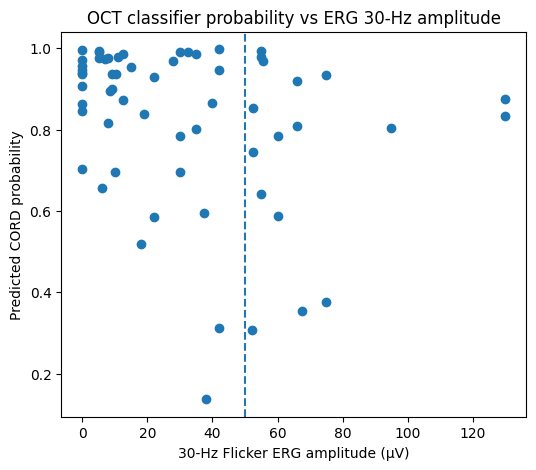


Saved predictions: /content/drive/MyDrive/CORD project/OCT_classifier_test_predictions_clean.csv
Saved model: /content/drive/MyDrive/CORD project/OCT_classifier_model_clean.keras


In [6]:
# ============================================================
# STEP 3A - OCT CLASSIFICATION
# CORD vs Normal using EfficientNetB0
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "OCT"
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 15

train_df = df[(df["Split"] == "Train") & (df["Modality"] == MODALITY)].copy()
test_df  = df[(df["Split"] == "Test") & (df["Modality"] == MODALITY)].copy()

print("Training set:")
print(train_df["Label"].value_counts())

print("\nTest set:")
print(test_df["Label"].value_counts())

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["Class"].values)
).map(load_image).shuffle(300, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["Class"].values)
).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

# ============================================================
# Evaluation
# ============================================================

probs = model.predict(test_ds).ravel()
preds = (probs >= 0.5).astype(int)

test_df = test_df.copy()
test_df["Pred_CORD_Probability"] = probs
test_df["Pred_Class"] = preds
test_df["Pred_Label"] = test_df["Pred_Class"].map({1: "CORD", 0: "Normal"})

print("\nConfusion matrix:")
print(confusion_matrix(test_df["Class"], preds))

print("\nClassification report:")
print(classification_report(test_df["Class"], preds, target_names=["Normal", "CORD"]))

print("\nAUC:")
print(roc_auc_score(test_df["Class"], probs))

# ============================================================
# ERG correlation inside CORD test images
# ============================================================

cord_erg = test_df[
    (test_df["Label"] == "CORD") &
    (test_df["ERG30Hz"].notna())
].copy()

from scipy.stats import pearsonr, spearmanr

print("\nERG-linked CORD OCT test images:", len(cord_erg))

print("\nSpearman correlation:")
print(spearmanr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

print("\nPearson correlation:")
print(pearsonr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

plt.figure(figsize=(6,5))
plt.scatter(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"])
plt.axvline(50, linestyle="--")
plt.xlabel("30-Hz Flicker ERG amplitude (µV)")
plt.ylabel("Predicted CORD probability")
plt.title("OCT classifier probability vs ERG 30-Hz amplitude")
plt.show()

# Save outputs
OUT_PATH = PROJECT_ROOT + "/OCT_classifier_test_predictions_clean.csv"
MODEL_PATH = PROJECT_ROOT + "/OCT_classifier_model_clean.keras"

test_df.to_csv(OUT_PATH, index=False)
model.save(MODEL_PATH)

print("\nSaved predictions:", OUT_PATH)
print("Saved model:", MODEL_PATH)

Training set:
Label
CORD      74
Normal    68
Name: count, dtype: int64

Test set:
Label
CORD      47
Normal     9
Name: count, dtype: int64
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.5775 - auc: 0.6352 - loss: 0.6856 - val_accuracy: 0.8571 - val_auc: 0.8783 - val_loss: 0.5344
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6338 - auc: 0.7496 - loss: 0.6144 - val_accuracy: 0.8571 - val_auc: 0.9196 - val_loss: 0.5687
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7394 - auc: 0.8054 - loss: 0.5834 - val_accuracy: 0.7857 - val_auc: 0.9338 - val_loss: 0.5781
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7394 - auc: 0.8063 - loss: 0.5682 - val_accuracy: 0.8571 - val_auc: 0.9421 - val_loss: 0.5372
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8310 - auc: 0.9018 - loss: 0.4942 - val_accuracy: 0.8750 - val_auc: 0.9480 - val_loss: 0.5080
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8310 - auc: 0.917

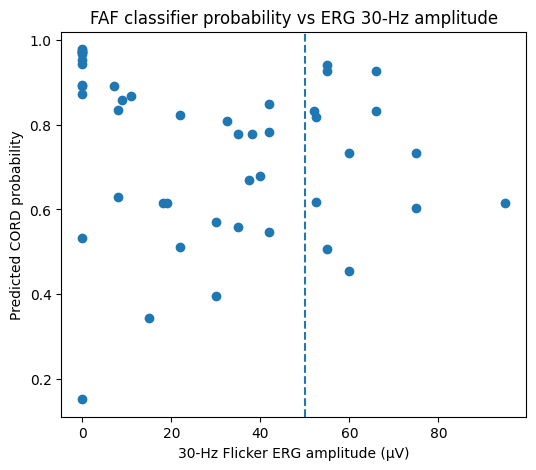


Saved predictions: /content/drive/MyDrive/CORD project/FAF_classifier_test_predictions_clean.csv
Saved model: /content/drive/MyDrive/CORD project/FAF_classifier_model_clean.keras


In [7]:
# ============================================================
# STEP 3B - FAF CLASSIFICATION
# CORD vs Normal using EfficientNetB0
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "FAF"
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 15

train_df = df[(df["Split"] == "Train") & (df["Modality"] == MODALITY)].copy()
test_df  = df[(df["Split"] == "Test") & (df["Modality"] == MODALITY)].copy()

print("Training set:")
print(train_df["Label"].value_counts())

print("\nTest set:")
print(test_df["Label"].value_counts())

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["Class"].values)
).map(load_image).shuffle(300, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["Class"].values)
).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

# ============================================================
# Evaluation
# ============================================================

probs = model.predict(test_ds).ravel()
preds = (probs >= 0.5).astype(int)

test_df = test_df.copy()
test_df["Pred_CORD_Probability"] = probs
test_df["Pred_Class"] = preds
test_df["Pred_Label"] = test_df["Pred_Class"].map({1: "CORD", 0: "Normal"})

print("\nConfusion matrix:")
print(confusion_matrix(test_df["Class"], preds))

print("\nClassification report:")
print(classification_report(test_df["Class"], preds, target_names=["Normal", "CORD"]))

print("\nAUC:")
print(roc_auc_score(test_df["Class"], probs))

# ============================================================
# ERG correlation inside CORD test images
# ============================================================

cord_erg = test_df[
    (test_df["Label"] == "CORD") &
    (test_df["ERG30Hz"].notna())
].copy()

print("\nERG-linked CORD FAF test images:", len(cord_erg))

print("\nSpearman correlation:")
print(spearmanr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

print("\nPearson correlation:")
print(pearsonr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

plt.figure(figsize=(6,5))
plt.scatter(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"])
plt.axvline(50, linestyle="--")
plt.xlabel("30-Hz Flicker ERG amplitude (µV)")
plt.ylabel("Predicted CORD probability")
plt.title("FAF classifier probability vs ERG 30-Hz amplitude")
plt.show()

# Save outputs
OUT_PATH = PROJECT_ROOT + "/FAF_classifier_test_predictions_clean.csv"
MODEL_PATH = PROJECT_ROOT + "/FAF_classifier_model_clean.keras"

test_df.to_csv(OUT_PATH, index=False)
model.save(MODEL_PATH)

print("\nSaved predictions:", OUT_PATH)
print("Saved model:", MODEL_PATH)

Training set:
Label
CORD      59
Normal    56
Name: count, dtype: int64

Test set:
Label
Normal    45
CORD      41
Name: count, dtype: int64
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 96s 7s/step - accuracy: 0.5043 - auc: 0.4623 - loss: 0.7434 - val_accuracy: 0.6744 - val_auc: 0.7943 - val_loss: 0.6362
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.6348 - auc: 0.7022 - loss: 0.6373 - val_accuracy: 0.8953 - val_auc: 0.9518 - val_loss: 0.5847
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.7826 - auc: 0.8860 - loss: 0.5274 - val_accuracy: 0.8837 - val_auc: 0.9596 - val_loss: 0.5417
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8522 - auc: 0.9451 - loss: 0.4819 - val_accuracy: 0.8605 - val_auc: 0.9466 - val_loss: 0.5074
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9130 - auc: 0.9753 - loss: 0.4143 - val_accuracy: 0.8721 - val_auc: 0.9293 - val_loss: 0.4818
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9391 - auc: 0.990

5/6 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

Confusion matrix:
[[43  2]
 [ 7 34]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.86      0.96      0.91        45
        CORD       0.94      0.83      0.88        41

    accuracy                           0.90        86
   macro avg       0.90      0.89      0.89        86
weighted avg       0.90      0.90      0.89        86


AUC:
0.9799457994579945

ERG-linked CORD FF test images: 41

Spearman correlation:
SignificanceResult(statistic=np.float64(-0.3916241105616269), pvalue=np.float64(0.011337768680246389))

Pearson correlation:
PearsonRResult(statistic=np.float64(-0.5649895178850238), pvalue=np.float64(0.00011884802958145939))


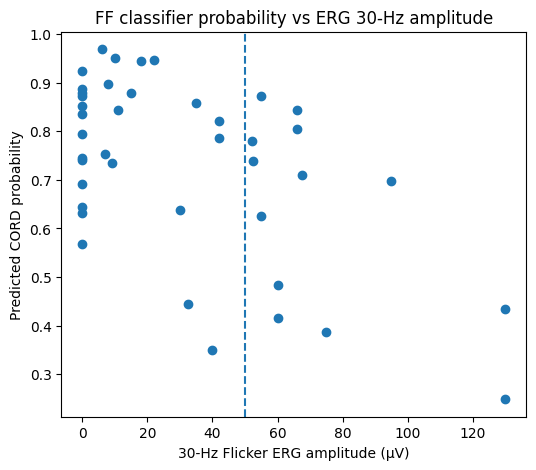


Saved predictions: /content/drive/MyDrive/CORD project/FF_classifier_test_predictions_clean.csv
Saved model: /content/drive/MyDrive/CORD project/FF_classifier_model_clean.keras


In [8]:
# ============================================================
# STEP 3C - Fundus Photo (FF) CLASSIFICATION
# CORD vs Normal using EfficientNetB0
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "FF"
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 15

train_df = df[(df["Split"] == "Train") & (df["Modality"] == MODALITY)].copy()
test_df  = df[(df["Split"] == "Test") & (df["Modality"] == MODALITY)].copy()

print("Training set:")
print(train_df["Label"].value_counts())

print("\nTest set:")
print(test_df["Label"].value_counts())

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["Class"].values)
).map(load_image).shuffle(300, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["Class"].values)
).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

# ============================================================
# Evaluation
# ============================================================

probs = model.predict(test_ds).ravel()
preds = (probs >= 0.5).astype(int)

test_df = test_df.copy()
test_df["Pred_CORD_Probability"] = probs
test_df["Pred_Class"] = preds
test_df["Pred_Label"] = test_df["Pred_Class"].map({1: "CORD", 0: "Normal"})

print("\nConfusion matrix:")
print(confusion_matrix(test_df["Class"], preds))

print("\nClassification report:")
print(classification_report(test_df["Class"], preds, target_names=["Normal", "CORD"]))

print("\nAUC:")
print(roc_auc_score(test_df["Class"], probs))

# ============================================================
# ERG correlation inside CORD test images
# ============================================================

cord_erg = test_df[
    (test_df["Label"] == "CORD") &
    (test_df["ERG30Hz"].notna())
].copy()

print("\nERG-linked CORD FF test images:", len(cord_erg))

print("\nSpearman correlation:")
print(spearmanr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

print("\nPearson correlation:")
print(pearsonr(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"]))

plt.figure(figsize=(6,5))
plt.scatter(cord_erg["ERG30Hz"], cord_erg["Pred_CORD_Probability"])
plt.axvline(50, linestyle="--")
plt.xlabel("30-Hz Flicker ERG amplitude (µV)")
plt.ylabel("Predicted CORD probability")
plt.title("FF classifier probability vs ERG 30-Hz amplitude")
plt.show()

# Save outputs
OUT_PATH = PROJECT_ROOT + "/FF_classifier_test_predictions_clean.csv"
MODEL_PATH = PROJECT_ROOT + "/FF_classifier_model_clean.keras"

test_df.to_csv(OUT_PATH, index=False)
model.save(MODEL_PATH)

print("\nSaved predictions:", OUT_PATH)
print("Saved model:", MODEL_PATH)

In [9]:
# ============================================================
# STEP 4 - VISUALIZE CNN TRAINING RESULTS
# OCT vs FAF vs FF
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Manually entered from your training logs
data = {
    "Epoch": list(range(1, 16)),

    "OCT_train_acc": [0.5610,0.7683,0.8293,0.8537,0.8902,0.9024,0.8963,0.8963,0.9329,0.9207,0.9329,0.9329,0.9146,0.9329,0.9451],
    "OCT_val_acc":   [0.8039,0.8529,0.8627,0.8725,0.8725,0.8824,0.8922,0.9020,0.9118,0.9020,0.9216,0.9216,0.9314,0.9216,0.9216],
    "OCT_val_auc":   [0.8907,0.9228,0.9413,0.9502,0.9563,0.9649,0.9700,0.9734,0.9754,0.9778,0.9790,0.9835,0.9863,0.9879,0.9885],

    "FAF_train_acc": [0.5775,0.6338,0.7394,0.7394,0.8310,0.8310,0.9014,0.8873,0.8944,0.9225,0.9014,0.9085,0.9014,0.9155,0.9155],
    "FAF_val_acc":   [0.8571,0.8571,0.7857,0.8571,0.8750,0.8750,0.8750,0.8036,0.8929,0.8929,0.8571,0.8571,0.8571,0.8750,0.9107],
    "FAF_val_auc":   [0.8783,0.9196,0.9338,0.9421,0.9480,0.9539,0.9563,0.9586,0.9610,0.9610,0.9598,0.9598,0.9586,0.9563,0.9504],

    "FF_train_acc":  [0.5043,0.6348,0.7826,0.8522,0.9130,0.9391,0.9217,0.9739,0.9304,0.9652,0.9565,0.9652,0.9913,0.9913,0.9913],
    "FF_val_acc":    [0.6744,0.8953,0.8837,0.8605,0.8721,0.8605,0.8605,0.8837,0.8837,0.8953,0.8837,0.8953,0.8953,0.8953,0.8953],
    "FF_val_auc":    [0.7943,0.9518,0.9596,0.9466,0.9293,0.9333,0.9396,0.9415,0.9466,0.9591,0.9637,0.9713,0.9759,0.9791,0.9799],
}

results = pd.DataFrame(data)
results.head()

,Epoch,OCT_train_acc,OCT_val_acc,OCT_val_auc,FAF_train_acc,FAF_val_acc,FAF_val_auc,FF_train_acc,FF_val_acc,FF_val_auc
0,1,0.5610,0.8039,0.8907,0.5775,0.8571,0.8783,0.5043,0.6744,0.7943
1,2,0.7683,0.8529,0.9228,0.6338,0.8571,0.9196,0.6348,0.8953,0.9518
2,3,0.8293,0.8627,0.9413,0.7394,0.7857,0.9338,0.7826,0.8837,0.9596
3,4,0.8537,0.8725,0.9502,0.7394,0.8571,0.9421,0.8522,0.8605,0.9466
4,5,0.8902,0.8725,0.9563,0.8310,0.8750,0.9480,0.9130,0.8721,0.9293


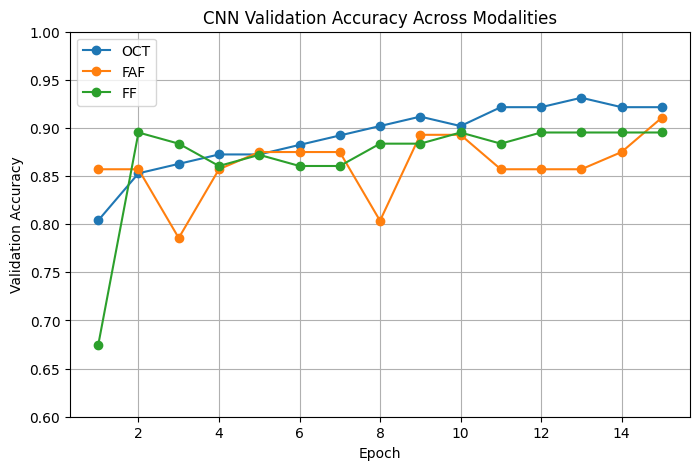

In [10]:
plt.figure(figsize=(8,5))
plt.plot(results["Epoch"], results["OCT_val_acc"], marker="o", label="OCT")
plt.plot(results["Epoch"], results["FAF_val_acc"], marker="o", label="FAF")
plt.plot(results["Epoch"], results["FF_val_acc"], marker="o", label="FF")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CNN Validation Accuracy Across Modalities")
plt.ylim(0.6, 1.0)
plt.legend()
plt.grid(True)
plt.show()

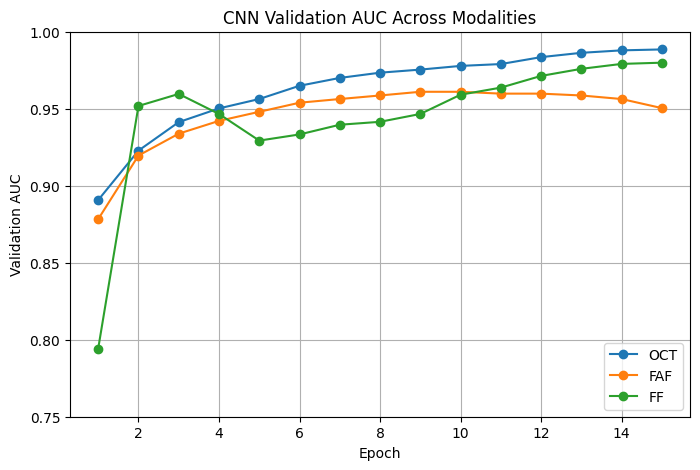

In [11]:
plt.figure(figsize=(8,5))
plt.plot(results["Epoch"], results["OCT_val_auc"], marker="o", label="OCT")
plt.plot(results["Epoch"], results["FAF_val_auc"], marker="o", label="FAF")
plt.plot(results["Epoch"], results["FF_val_auc"], marker="o", label="FF")
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("CNN Validation AUC Across Modalities")
plt.ylim(0.75, 1.0)
plt.legend()
plt.grid(True)
plt.show()

,Modality,Accuracy,AUC,Spearman_r,Pearson_r
0,OCT,0.9216,0.9885,-0.321,-0.263
1,FAF,0.9107,0.9504,-0.401,-0.221
2,FF,0.8953,0.9799,-0.392,-0.565


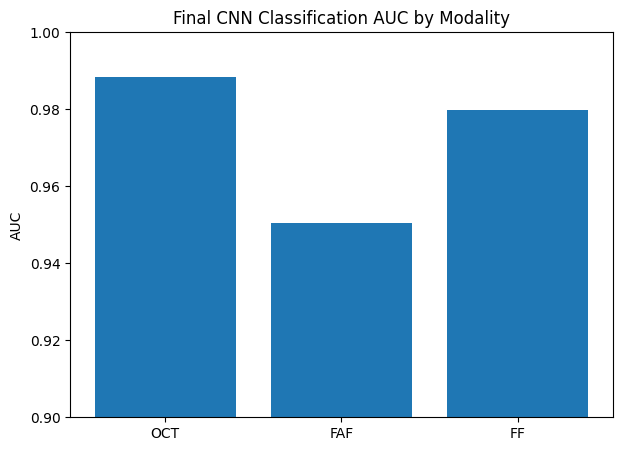

In [12]:
summary = pd.DataFrame({
    "Modality": ["OCT", "FAF", "FF"],
    "Accuracy": [0.9216, 0.9107, 0.8953],
    "AUC": [0.9885, 0.9504, 0.9799],
    "Spearman_r": [-0.321, -0.401, -0.392],
    "Pearson_r": [-0.263, -0.221, -0.565]
})

display(summary)

plt.figure(figsize=(7,5))
plt.bar(summary["Modality"], summary["AUC"])
plt.ylabel("AUC")
plt.title("Final CNN Classification AUC by Modality")
plt.ylim(0.9, 1.0)
plt.show()

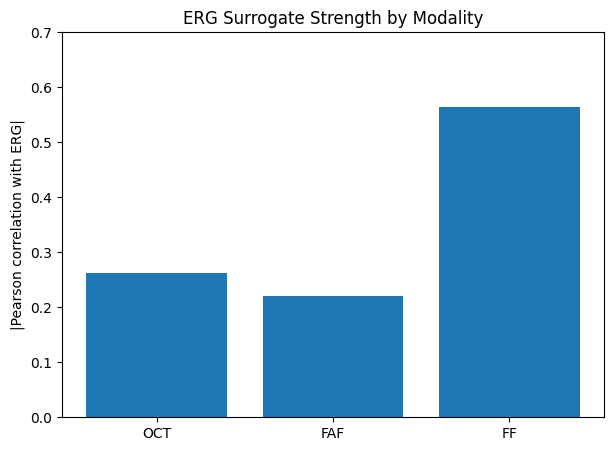

In [13]:
plt.figure(figsize=(7,5))
plt.bar(summary["Modality"], summary["Pearson_r"].abs())
plt.ylabel("|Pearson correlation with ERG|")
plt.title("ERG Surrogate Strength by Modality")
plt.ylim(0, 0.7)
plt.show()

In [14]:
# ============================================================
# STEP 5 - COMBINE OCT / FAF / FF RESULTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

files = {
    "OCT": PROJECT_ROOT + "/OCT_classifier_test_predictions_clean.csv",
    "FAF": PROJECT_ROOT + "/FAF_classifier_test_predictions_clean.csv",
    "FF":  PROJECT_ROOT + "/FF_classifier_test_predictions_clean.csv",
}

rows = []

for modality, path in files.items():
    df = pd.read_csv(path)

    y_true = df["Class"]
    y_prob = df["Pred_CORD_Probability"]
    y_pred = df["Pred_Class"]

    accuracy = (y_true == y_pred).mean()

    cord = df[(df["Label"] == "CORD") & (df["ERG30Hz"].notna())].copy()

    pearson = pearsonr(cord["ERG30Hz"], cord["Pred_CORD_Probability"])
    spearman = spearmanr(cord["ERG30Hz"], cord["Pred_CORD_Probability"])

    rows.append({
        "Modality": modality,
        "Test_N": len(df),
        "CORD_N": sum(df["Label"] == "CORD"),
        "Normal_N": sum(df["Label"] == "Normal"),
        "Accuracy": accuracy,
        "Pearson_r": pearson.statistic,
        "Pearson_p": pearson.pvalue,
        "Spearman_r": spearman.statistic,
        "Spearman_p": spearman.pvalue,
    })

summary = pd.DataFrame(rows)
display(summary)

summary.to_csv(PROJECT_ROOT + "/modality_comparison_summary.csv", index=False)
print("Saved:", PROJECT_ROOT + "/modality_comparison_summary.csv")

,Modality,Test_N,CORD_N,Normal_N,Accuracy,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,OCT,102,60,42,0.921569,-0.262627,0.042637,-0.321239,0.012326
1,FAF,56,47,9,0.910714,-0.221449,0.134670,-0.400761,0.005245
2,FF,86,41,45,0.895349,-0.564990,0.000119,-0.391624,0.011338


Saved: /content/drive/MyDrive/CORD project/modality_comparison_summary.csv


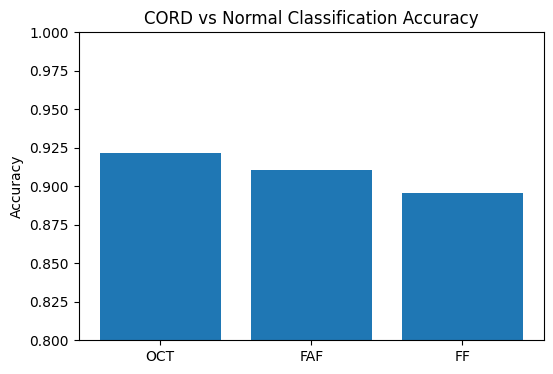

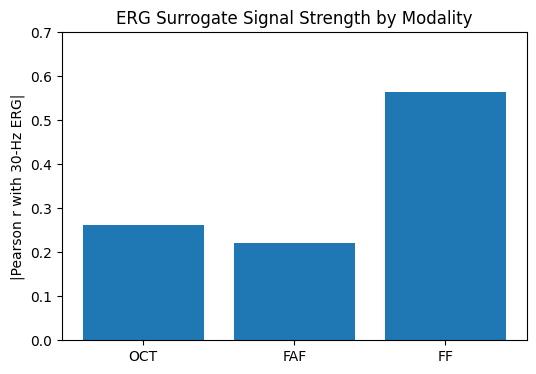

In [15]:
# Accuracy plot
plt.figure(figsize=(6,4))
plt.bar(summary["Modality"], summary["Accuracy"])
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("CORD vs Normal Classification Accuracy")
plt.show()

# ERG correlation plot
plt.figure(figsize=(6,4))
plt.bar(summary["Modality"], summary["Pearson_r"].abs())
plt.ylim(0, 0.7)
plt.ylabel("|Pearson r with 30-Hz ERG|")
plt.title("ERG Surrogate Signal Strength by Modality")
plt.show()

FF ERG-linked cases: 41


,CaseID,filename,ERG30Hz
0,8.0,Case 8 - FF.png,10.0
1,9.0,Case 9 - FF.png,5.9
2,14.0,Case 14 - FF.png,9.0
3,15.0,Case 15 - FF.png,11.0
4,22.0,Case 22 - FF.png,22.0


Image tensor: (41, 224, 224, 3)
ERG range: 0.0 - 130.0
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 854ms/step
Feature matrix: (41, 1280)

===== FF → ERG Regression Results =====
N: 41
MAE: 18.34875798933305
RMSE: 24.534932183478663
R²: 0.5018534022436961
Pearson r: PearsonRResult(statistic=np.float64(0.7091648421089465), pvalue=np.float64(2.1054687950323034e-07))
Spearman r: SignificanceResult(statistic=np.float64(0.7506645284516105), pvalue=np.float64(1.585103861604806e-08))


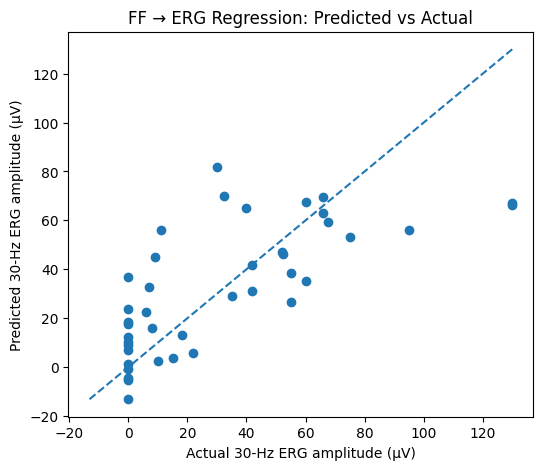

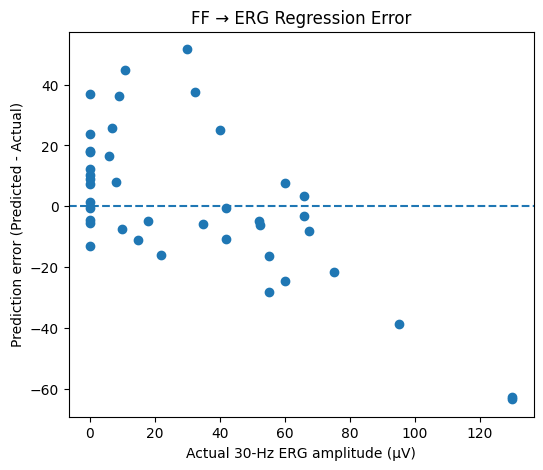


Saved: /content/drive/MyDrive/CORD project/FF_ERG_regression_predictions.csv


In [16]:
# ============================================================
# STEP 6 - FF → ERG REGRESSION
# EfficientNet feature extraction + Ridge regression
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "FF"
IMG_SIZE = 224

# Use only CORD images with real ERG values
reg_df = df[
    (df["Split"] == "Test") &
    (df["Label"] == "CORD") &
    (df["Modality"] == MODALITY) &
    (df["ERG30Hz"].notna())
].copy()

reg_df = reg_df.sort_values("CaseID").reset_index(drop=True)

print("FF ERG-linked cases:", len(reg_df))
display(reg_df[["CaseID", "filename", "ERG30Hz"]].head())

# ============================================================
# Image preprocessing
# ============================================================

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img.numpy()

X_imgs = np.stack([load_img_array(p) for p in reg_df["filepath"].values])
y = reg_df["ERG30Hz"].values.astype(float)

print("Image tensor:", X_imgs.shape)
print("ERG range:", y.min(), "-", y.max())

# ============================================================
# Feature extractor
# ============================================================

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

features = base.predict(X_imgs, batch_size=8)

print("Feature matrix:", features.shape)

# ============================================================
# Ridge regression with Leave-One-Out Cross-Validation
# ============================================================

alphas = np.logspace(-3, 3, 30)

model = RidgeCV(alphas=alphas)

loo = LeaveOneOut()
pred = cross_val_predict(model, features, y, cv=loo)

# Fit final model on all data
model.fit(features, y)

reg_df["Predicted_ERG30Hz"] = pred
reg_df["Prediction_Error"] = reg_df["Predicted_ERG30Hz"] - reg_df["ERG30Hz"]

# ============================================================
# Metrics
# ============================================================

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
r2 = r2_score(y, pred)

pearson = pearsonr(y, pred)
spearman = spearmanr(y, pred)

print("\n===== FF → ERG Regression Results =====")
print("N:", len(y))
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Pearson r:", pearson)
print("Spearman r:", spearman)

# ============================================================
# Plot predicted vs actual
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(y, pred)

min_val = min(y.min(), pred.min())
max_val = max(y.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
plt.title("FF → ERG Regression: Predicted vs Actual")
plt.show()

# ============================================================
# Error plot
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(y, reg_df["Prediction_Error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Prediction error (Predicted - Actual)")
plt.title("FF → ERG Regression Error")
plt.show()

# ============================================================
# Save results
# ============================================================

OUT_PATH = PROJECT_ROOT + "/FF_ERG_regression_predictions.csv"
reg_df.to_csv(OUT_PATH, index=False)

print("\nSaved:", OUT_PATH)

OCT ERG-linked cases: 60


,CaseID,filename,ERG30Hz
0,1.0,Case 1 - OCT.png,35.0
1,2.0,Case 2 - OCT.png,75.0
2,3.0,Case 3 - OCT.png,55.0
3,4.0,Case 4 - OCT.png,38.0
4,5.0,Case 5 - OCT.png,42.0


Image tensor: (60, 224, 224, 3)
ERG range: 0.0 - 130.0
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Feature matrix: (60, 1280)

===== OCT → ERG Regression Results =====
N: 60
MAE: 21.009173190982082
RMSE: 26.03091093391503
R²: 0.2655372843646048
Pearson r: PearsonRResult(statistic=np.float64(0.5203980207016689), pvalue=np.float64(2.025819156390835e-05))
Spearman r: SignificanceResult(statistic=np.float64(0.4885308957836863), pvalue=np.float64(7.490627001686193e-05))


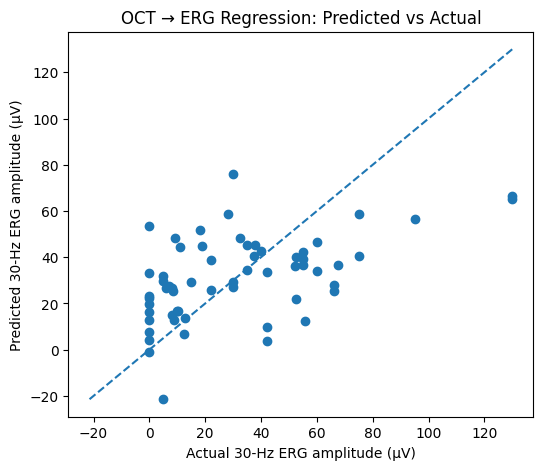

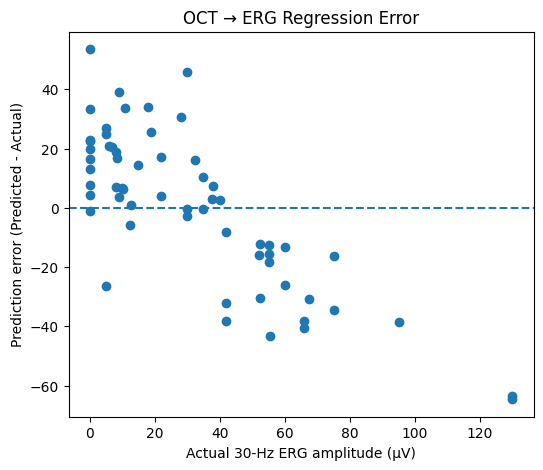


Saved: /content/drive/MyDrive/CORD project/OCT_ERG_regression_predictions.csv


In [17]:
# ============================================================
# STEP 7 - OCT → ERG REGRESSION
# EfficientNet feature extraction + Ridge regression
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "OCT"
IMG_SIZE = 224

reg_df = df[
    (df["Split"] == "Test") &
    (df["Label"] == "CORD") &
    (df["Modality"] == MODALITY) &
    (df["ERG30Hz"].notna())
].copy()

reg_df = reg_df.sort_values("CaseID").reset_index(drop=True)

print("OCT ERG-linked cases:", len(reg_df))
display(reg_df[["CaseID", "filename", "ERG30Hz"]].head())

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img.numpy()

X_imgs = np.stack([load_img_array(p) for p in reg_df["filepath"].values])
y = reg_df["ERG30Hz"].values.astype(float)

print("Image tensor:", X_imgs.shape)
print("ERG range:", y.min(), "-", y.max())

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

features = base.predict(X_imgs, batch_size=8)

print("Feature matrix:", features.shape)

alphas = np.logspace(-3, 3, 30)
model = RidgeCV(alphas=alphas)

loo = LeaveOneOut()
pred = cross_val_predict(model, features, y, cv=loo)

model.fit(features, y)

reg_df["Predicted_ERG30Hz"] = pred
reg_df["Prediction_Error"] = reg_df["Predicted_ERG30Hz"] - reg_df["ERG30Hz"]

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
r2 = r2_score(y, pred)

pearson = pearsonr(y, pred)
spearman = spearmanr(y, pred)

print("\n===== OCT → ERG Regression Results =====")
print("N:", len(y))
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Pearson r:", pearson)
print("Spearman r:", spearman)

plt.figure(figsize=(6,5))
plt.scatter(y, pred)

min_val = min(y.min(), pred.min())
max_val = max(y.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
plt.title("OCT → ERG Regression: Predicted vs Actual")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(y, reg_df["Prediction_Error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Prediction error (Predicted - Actual)")
plt.title("OCT → ERG Regression Error")
plt.show()

OUT_PATH = PROJECT_ROOT + "/OCT_ERG_regression_predictions.csv"
reg_df.to_csv(OUT_PATH, index=False)

print("\nSaved:", OUT_PATH)

FAF ERG-linked cases: 47


,CaseID,filename,ERG30Hz
0,1.0,Case 1 - FAF.png,35.0
1,2.0,Case 2 - FAF.png,75.0
2,3.0,Case 3 - FAF.png,55.0
3,4.0,Case 4 - FAF.png,38.0
4,5.0,Case 5 - FAF.png,42.0


Image tensor: (47, 224, 224, 3)
ERG range: 0.0 - 95.0
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Feature matrix: (47, 1280)

===== FAF → ERG Regression Results =====
N: 47
MAE: 16.661983288794683
RMSE: 20.616722783452882
R²: 0.36205241210758565
Pearson r: PearsonRResult(statistic=np.float64(0.6103933209476436), pvalue=np.float64(5.223521855406191e-06))
Spearman r: SignificanceResult(statistic=np.float64(0.6000603995353497), pvalue=np.float64(8.270244155201763e-06))


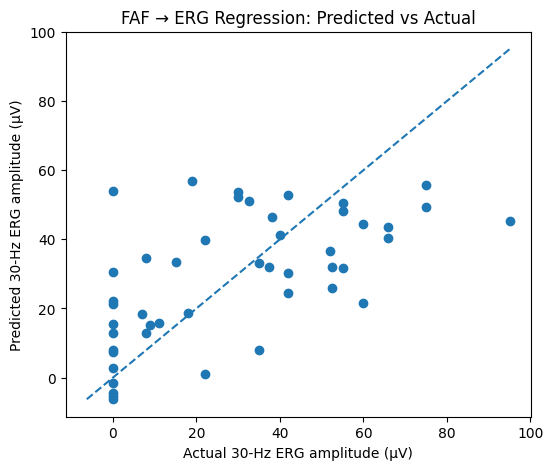

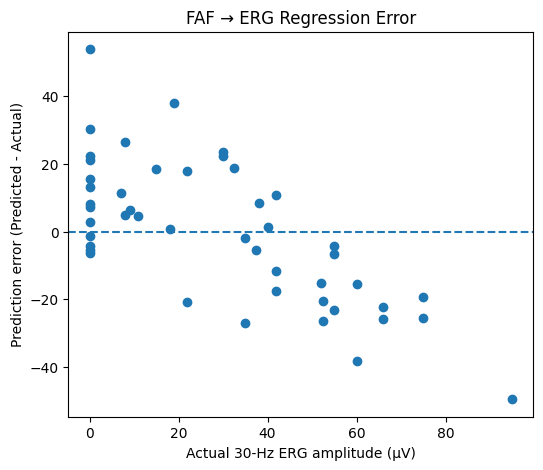


Saved: /content/drive/MyDrive/CORD project/FAF_ERG_regression_predictions.csv


In [18]:
# ============================================================
# STEP 8 - FAF → ERG REGRESSION
# EfficientNet feature extraction + Ridge regression
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

MODALITY = "FAF"
IMG_SIZE = 224

reg_df = df[
    (df["Split"] == "Test") &
    (df["Label"] == "CORD") &
    (df["Modality"] == MODALITY) &
    (df["ERG30Hz"].notna())
].copy()

reg_df = reg_df.sort_values("CaseID").reset_index(drop=True)

print("FAF ERG-linked cases:", len(reg_df))
display(reg_df[["CaseID", "filename", "ERG30Hz"]].head())

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img.numpy()

X_imgs = np.stack([load_img_array(p) for p in reg_df["filepath"].values])
y = reg_df["ERG30Hz"].values.astype(float)

print("Image tensor:", X_imgs.shape)
print("ERG range:", y.min(), "-", y.max())

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

features = base.predict(X_imgs, batch_size=8)

print("Feature matrix:", features.shape)

alphas = np.logspace(-3, 3, 30)
model = RidgeCV(alphas=alphas)

loo = LeaveOneOut()
pred = cross_val_predict(model, features, y, cv=loo)

model.fit(features, y)

reg_df["Predicted_ERG30Hz"] = pred
reg_df["Prediction_Error"] = reg_df["Predicted_ERG30Hz"] - reg_df["ERG30Hz"]

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
r2 = r2_score(y, pred)

pearson = pearsonr(y, pred)
spearman = spearmanr(y, pred)

print("\n===== FAF → ERG Regression Results =====")
print("N:", len(y))
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Pearson r:", pearson)
print("Spearman r:", spearman)

plt.figure(figsize=(6,5))
plt.scatter(y, pred)

min_val = min(y.min(), pred.min())
max_val = max(y.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
plt.title("FAF → ERG Regression: Predicted vs Actual")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(y, reg_df["Prediction_Error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Prediction error (Predicted - Actual)")
plt.title("FAF → ERG Regression Error")
plt.show()

OUT_PATH = PROJECT_ROOT + "/FAF_ERG_regression_predictions.csv"
reg_df.to_csv(OUT_PATH, index=False)

print("\nSaved:", OUT_PATH)

Common multimodal cases: 33
[14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63]

Multimodal table:


,CaseID,ERG30Hz,OCT_path,FAF_path,FF_path,OCT_file,FAF_file,FF_file
0,14,9.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 14 - OCT.png,Case 14 - FAF.png,Case 14 - FF.png
1,15,11.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 15 - OCT.png,Case 15 - FAF.png,Case 15 - FF.png
2,22,22.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 22 - OCT.png,Case 22 - FAF.png,Case 22 - FF.png
3,23,18.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 23 - OCT.png,Case 23 - FAF.png,Case 23 - FF.png
4,24,15.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 24 - OCT.png,Case 24 - FAF.png,Case 24 - FF.png


N: 33
ERG range: 0.0 - 95.0
OCT tensor: (33, 224, 224, 3)
FAF tensor: (33, 224, 224, 3)
FF tensor: (33, 224, 224, 3)
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step
OCT features: (33, 1280)
FAF features: (33, 1280)
FF features: (33, 1280)
Combined feature matrix: (33, 3840)

===== Multimodal OCT+FAF+FF → ERG Regression Results =====
N: 33
MAE: 11.677605609468198
RMSE: 15.045316490952526
R²: 0.6950556322167294
Pearson r: PearsonRResult(statistic=np.float64(0.842269953950551), pvalue=np.float64(7.993056262535171e-10))
Spearman r: SignificanceResult(statistic=np.float64(0.8442259370495744), pvalue=np.float64(6.682380180512424e-10))


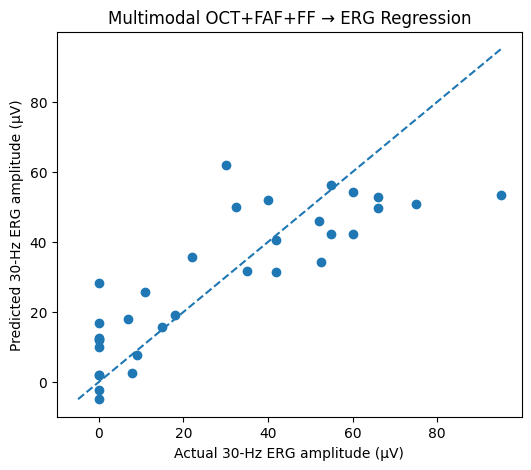

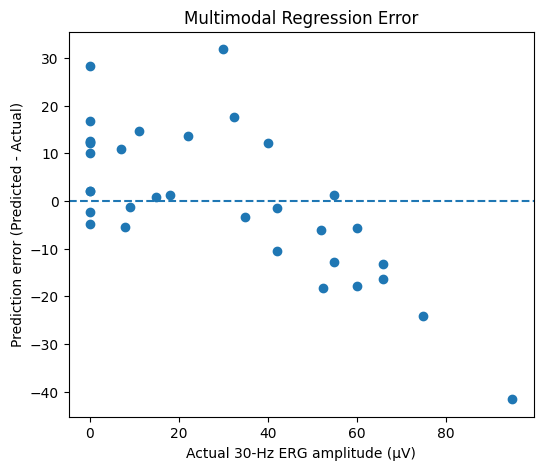


Saved: /content/drive/MyDrive/CORD project/MULTIMODAL_ERG_regression_predictions.csv


In [19]:
# ============================================================
# STEP 9 - MULTIMODAL FUSION MODEL
# OCT + FAF + FF → ERG regression
# EfficientNet feature extraction + Ridge regression
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

df = pd.read_csv(META_PATH)

IMG_SIZE = 224

# ============================================================
# 1. Select CORD test images with ERG
# ============================================================

cord = df[
    (df["Split"] == "Test") &
    (df["Label"] == "CORD") &
    (df["ERG30Hz"].notna())
].copy()

# Keep only CaseID-labelled images
cord = cord[cord["CaseID"].notna()].copy()
cord["CaseID"] = cord["CaseID"].astype(int)

# Find cases with all 3 modalities
case_sets = {}

for modality in ["OCT", "FAF", "FF"]:
    case_sets[modality] = set(
        cord[cord["Modality"] == modality]["CaseID"].astype(int)
    )

common_cases = sorted(
    case_sets["OCT"] & case_sets["FAF"] & case_sets["FF"]
)

print("Common multimodal cases:", len(common_cases))
print(common_cases)

# ============================================================
# 2. Build paired multimodal table
# ============================================================

rows = []

for case in common_cases:
    temp = cord[cord["CaseID"] == case]

    oct_row = temp[temp["Modality"] == "OCT"].iloc[0]
    faf_row = temp[temp["Modality"] == "FAF"].iloc[0]
    ff_row  = temp[temp["Modality"] == "FF"].iloc[0]

    erg = oct_row["ERG30Hz"]

    rows.append({
        "CaseID": case,
        "ERG30Hz": erg,
        "OCT_path": oct_row["filepath"],
        "FAF_path": faf_row["filepath"],
        "FF_path": ff_row["filepath"],
        "OCT_file": oct_row["filename"],
        "FAF_file": faf_row["filename"],
        "FF_file": ff_row["filename"],
    })

multi_df = pd.DataFrame(rows)

print("\nMultimodal table:")
display(multi_df.head())
print("N:", len(multi_df))
print("ERG range:", multi_df["ERG30Hz"].min(), "-", multi_df["ERG30Hz"].max())

# ============================================================
# 3. Image loading
# ============================================================

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img.numpy()

def load_image_stack(paths):
    return np.stack([load_img_array(p) for p in paths])

X_oct = load_image_stack(multi_df["OCT_path"].values)
X_faf = load_image_stack(multi_df["FAF_path"].values)
X_ff  = load_image_stack(multi_df["FF_path"].values)

y = multi_df["ERG30Hz"].values.astype(float)

print("OCT tensor:", X_oct.shape)
print("FAF tensor:", X_faf.shape)
print("FF tensor:", X_ff.shape)

# ============================================================
# 4. Feature extraction
# ============================================================

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

feat_oct = base.predict(X_oct, batch_size=8)
feat_faf = base.predict(X_faf, batch_size=8)
feat_ff  = base.predict(X_ff, batch_size=8)

print("OCT features:", feat_oct.shape)
print("FAF features:", feat_faf.shape)
print("FF features:", feat_ff.shape)

# Concatenate features
features = np.concatenate([feat_oct, feat_faf, feat_ff], axis=1)

print("Combined feature matrix:", features.shape)

# ============================================================
# 5. Ridge regression with Leave-One-Out CV
# ============================================================

alphas = np.logspace(-3, 3, 30)

model = RidgeCV(alphas=alphas)

loo = LeaveOneOut()
pred = cross_val_predict(model, features, y, cv=loo)

model.fit(features, y)

multi_df["Predicted_ERG30Hz"] = pred
multi_df["Prediction_Error"] = multi_df["Predicted_ERG30Hz"] - multi_df["ERG30Hz"]

# ============================================================
# 6. Metrics
# ============================================================

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
r2 = r2_score(y, pred)

pearson = pearsonr(y, pred)
spearman = spearmanr(y, pred)

print("\n===== Multimodal OCT+FAF+FF → ERG Regression Results =====")
print("N:", len(y))
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Pearson r:", pearson)
print("Spearman r:", spearman)

# ============================================================
# 7. Plot predicted vs actual
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(y, pred)

min_val = min(y.min(), pred.min())
max_val = max(y.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
plt.title("Multimodal OCT+FAF+FF → ERG Regression")
plt.show()

# ============================================================
# 8. Error plot
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(y, multi_df["Prediction_Error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Prediction error (Predicted - Actual)")
plt.title("Multimodal Regression Error")
plt.show()

# ============================================================
# 9. Save
# ============================================================

OUT_PATH = PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv"
multi_df.to_csv(OUT_PATH, index=False)

print("\nSaved:", OUT_PATH)

,Modality,Test_N,CORD_N,Normal_N,Accuracy,Sensitivity_CORD_Recall,Specificity_Normal_Recall,AUC,TP,TN,FP,FN
0,OCT,102,60,42,0.921569,0.916667,0.928571,0.988492,55,39,3,5
1,FAF,56,47,9,0.910714,0.914894,0.888889,0.950355,43,8,1,4
2,FF,86,41,45,0.895349,0.829268,0.955556,0.979946,34,43,2,7


,Model,N,MAE_uV,RMSE_uV,R2,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,FF,41,18.348758,24.534932,0.501853,0.709165,2.105469e-07,0.750665,1.585104e-08
1,OCT,60,21.009173,26.030911,0.265537,0.520398,2.025819e-05,0.488531,7.490627e-05
2,FAF,47,16.661983,20.616723,0.362052,0.610393,5.223522e-06,0.600060,8.270244e-06
3,Multimodal OCT+FAF+FF,33,11.677606,15.045316,0.695056,0.842270,7.993056e-10,0.844226,6.682380e-10


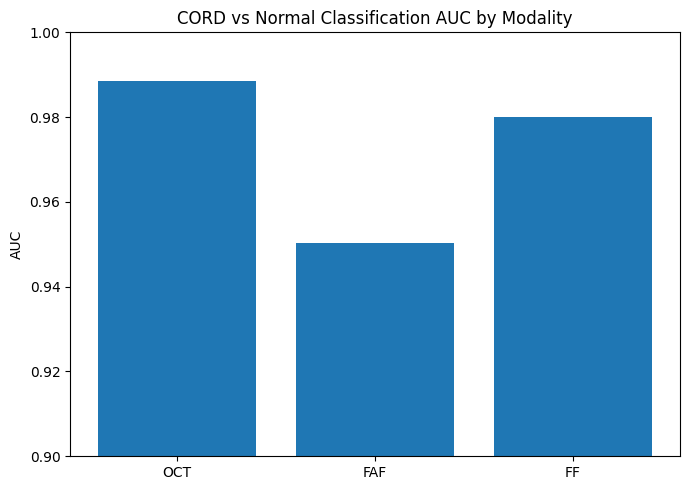

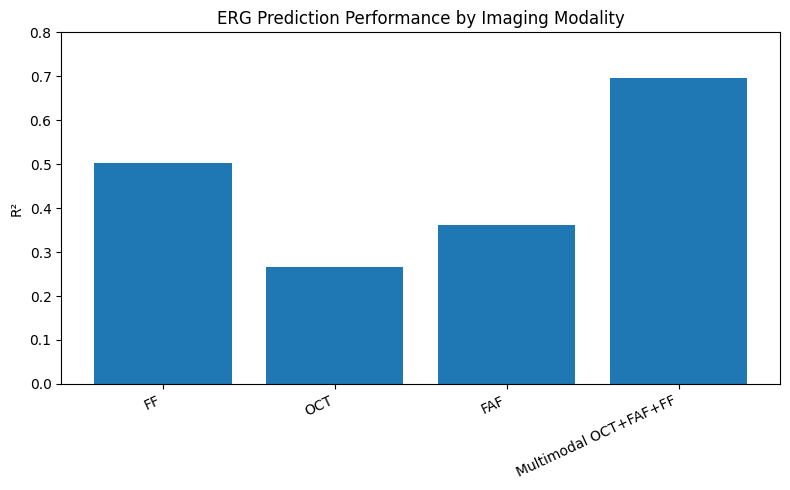

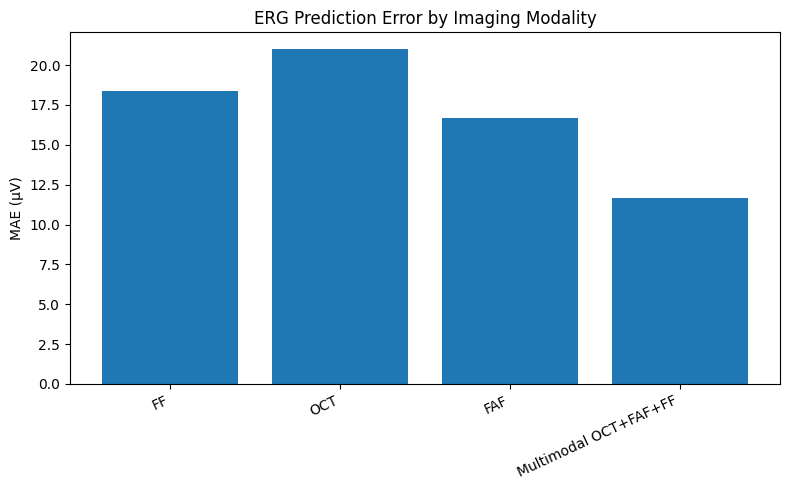

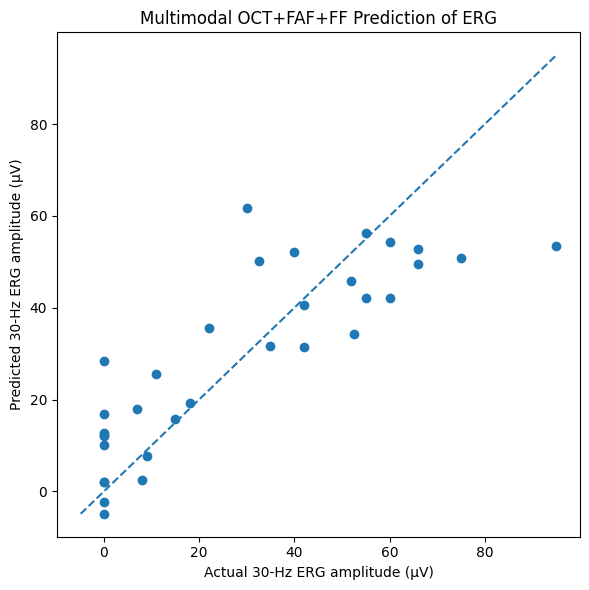

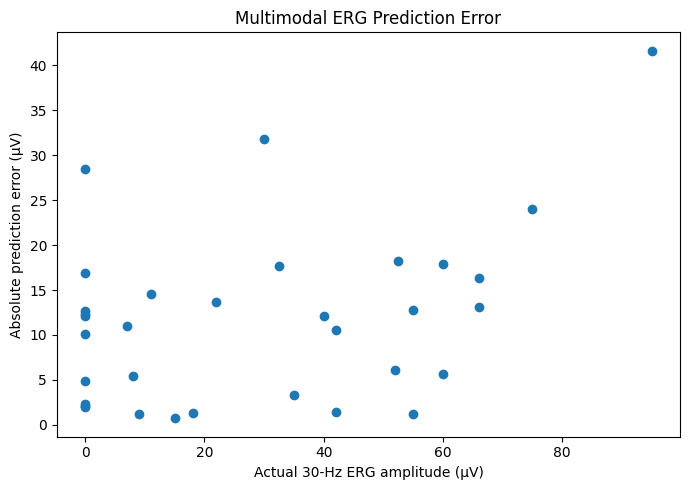

,CaseID,ERG30Hz,Predicted_ERG30Hz,Prediction_Error,Absolute_Error
13,36,95.0,53.406988,-41.593012,41.593012
9,30,30.0,61.836100,31.836100,31.836100
16,40,0.0,28.405923,28.405923,28.405923
12,35,75.0,50.955659,-24.044341,24.044341
23,52,52.5,34.286221,-18.213779,18.213779
8,29,60.0,42.144301,-17.855699,17.855699
11,34,32.5,50.115634,17.615634,17.615634
26,55,0.0,16.852341,16.852341,16.852341
27,56,66.0,49.628406,-16.371594,16.371594
1,15,11.0,25.599347,14.599347,14.599347



Final files saved in:
/content/drive/MyDrive/CORD project

Saved outputs:
FINAL_classification_summary.csv
FINAL_regression_summary.csv
FINAL_classification_AUC_plot.png
FINAL_regression_R2_plot.png
FINAL_regression_MAE_plot.png
FINAL_multimodal_predicted_vs_actual.png
FINAL_multimodal_absolute_error.png
FINAL_multimodal_error_analysis.csv


In [20]:
# ============================================================
# STEP 10 - FINAL RESULTS
# Summary tables + plots
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.stats import pearsonr, spearmanr

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

# -----------------------------
# 1. Classification summary
# -----------------------------

classification_files = {
    "OCT": PROJECT_ROOT + "/OCT_classifier_test_predictions_clean.csv",
    "FAF": PROJECT_ROOT + "/FAF_classifier_test_predictions_clean.csv",
    "FF":  PROJECT_ROOT + "/FF_classifier_test_predictions_clean.csv",
}

classification_rows = []

for modality, path in classification_files.items():
    df = pd.read_csv(path)

    y_true = df["Class"]
    y_pred = df["Pred_Class"]
    y_prob = df["Pred_CORD_Probability"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    classification_rows.append({
        "Modality": modality,
        "Test_N": len(df),
        "CORD_N": int(sum(df["Label"] == "CORD")),
        "Normal_N": int(sum(df["Label"] == "Normal")),
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Sensitivity_CORD_Recall": tp / (tp + fn),
        "Specificity_Normal_Recall": tn / (tn + fp),
        "AUC": roc_auc_score(y_true, y_prob),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

classification_summary = pd.DataFrame(classification_rows)

display(classification_summary)

classification_summary.to_csv(
    PROJECT_ROOT + "/FINAL_classification_summary.csv",
    index=False
)

# -----------------------------
# 2. Regression summary
# -----------------------------

regression_files = {
    "FF": PROJECT_ROOT + "/FF_ERG_regression_predictions.csv",
    "OCT": PROJECT_ROOT + "/OCT_ERG_regression_predictions.csv",
    "FAF": PROJECT_ROOT + "/FAF_ERG_regression_predictions.csv",
    "Multimodal OCT+FAF+FF": PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv",
}

regression_rows = []

for model_name, path in regression_files.items():
    df = pd.read_csv(path)

    y = df["ERG30Hz"].values
    pred = df["Predicted_ERG30Hz"].values

    mae = np.mean(np.abs(pred - y))
    rmse = np.sqrt(np.mean((pred - y) ** 2))
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    pearson = pearsonr(y, pred)
    spearman = spearmanr(y, pred)

    regression_rows.append({
        "Model": model_name,
        "N": len(df),
        "MAE_uV": mae,
        "RMSE_uV": rmse,
        "R2": r2,
        "Pearson_r": pearson.statistic,
        "Pearson_p": pearson.pvalue,
        "Spearman_r": spearman.statistic,
        "Spearman_p": spearman.pvalue
    })

regression_summary = pd.DataFrame(regression_rows)

display(regression_summary)

regression_summary.to_csv(
    PROJECT_ROOT + "/FINAL_regression_summary.csv",
    index=False
)

# -----------------------------
# 3. Plot: classification AUC
# -----------------------------

plt.figure(figsize=(7,5))
plt.bar(classification_summary["Modality"], classification_summary["AUC"])
plt.ylim(0.9, 1.0)
plt.ylabel("AUC")
plt.title("CORD vs Normal Classification AUC by Modality")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/FINAL_classification_AUC_plot.png", dpi=300)
plt.show()

# -----------------------------
# 4. Plot: regression R2
# -----------------------------

plt.figure(figsize=(8,5))
plt.bar(regression_summary["Model"], regression_summary["R2"])
plt.ylabel("R²")
plt.title("ERG Prediction Performance by Imaging Modality")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/FINAL_regression_R2_plot.png", dpi=300)
plt.show()

# -----------------------------
# 5. Plot: regression MAE
# -----------------------------

plt.figure(figsize=(8,5))
plt.bar(regression_summary["Model"], regression_summary["MAE_uV"])
plt.ylabel("MAE (µV)")
plt.title("ERG Prediction Error by Imaging Modality")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/FINAL_regression_MAE_plot.png", dpi=300)
plt.show()

# -----------------------------
# 6. Main plot: multimodal predicted vs actual
# -----------------------------

multi = pd.read_csv(PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv")

y = multi["ERG30Hz"].values
pred = multi["Predicted_ERG30Hz"].values

plt.figure(figsize=(6,6))
plt.scatter(y, pred)

min_val = min(y.min(), pred.min())
max_val = max(y.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
plt.title("Multimodal OCT+FAF+FF Prediction of ERG")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/FINAL_multimodal_predicted_vs_actual.png", dpi=300)
plt.show()

# -----------------------------
# 7. Multimodal error plot
# -----------------------------

multi["Absolute_Error"] = abs(multi["Predicted_ERG30Hz"] - multi["ERG30Hz"])

plt.figure(figsize=(7,5))
plt.scatter(multi["ERG30Hz"], multi["Absolute_Error"])
plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
plt.ylabel("Absolute prediction error (µV)")
plt.title("Multimodal ERG Prediction Error")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/FINAL_multimodal_absolute_error.png", dpi=300)
plt.show()

# -----------------------------
# 8. Worst predicted cases
# -----------------------------

worst_cases = multi.sort_values("Absolute_Error", ascending=False)

display(
    worst_cases[
        ["CaseID", "ERG30Hz", "Predicted_ERG30Hz", "Prediction_Error", "Absolute_Error"]
    ].head(10)
)

worst_cases.to_csv(
    PROJECT_ROOT + "/FINAL_multimodal_error_analysis.csv",
    index=False
)

print("\nFinal files saved in:")
print(PROJECT_ROOT)

print("\nSaved outputs:")
print("FINAL_classification_summary.csv")
print("FINAL_regression_summary.csv")
print("FINAL_classification_AUC_plot.png")
print("FINAL_regression_R2_plot.png")
print("FINAL_regression_MAE_plot.png")
print("FINAL_multimodal_predicted_vs_actual.png")
print("FINAL_multimodal_absolute_error.png")
print("FINAL_multimodal_error_analysis.csv")

In [3]:
# ============================================================
# STEP 11A - 95% CONFIDENCE INTERVALS
# Classification + Regression metrics
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.proportion import proportion_confint

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

RANDOM_SEED = 42
N_BOOT = 5000

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# Helper functions
# ============================================================

def bootstrap_ci(values, ci=95):
    """
    Return lower and upper percentile confidence interval.
    """
    lower = np.percentile(values, (100 - ci) / 2)
    upper = np.percentile(values, 100 - (100 - ci) / 2)
    return lower, upper


def safe_roc_auc(y_true, y_score):
    """
    AUC cannot be calculated if a bootstrap sample contains only one class.
    """
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def classification_metrics(y_true, y_pred, y_prob):
    """
    Calculate accuracy, sensitivity, specificity, and AUC.
    Assumption:
    Class 1 = CORD
    Class 0 = Normal
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc = safe_roc_auc(y_true, y_prob)

    return {
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": auc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


def regression_metrics(y, pred):
    """
    Calculate MAE, RMSE, R2, Pearson r, and Spearman r.
    """
    y = np.asarray(y)
    pred = np.asarray(pred)

    mae = np.mean(np.abs(pred - y))
    rmse = np.sqrt(np.mean((pred - y) ** 2))

    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    if len(np.unique(y)) > 1 and len(np.unique(pred)) > 1:
        pearson = pearsonr(y, pred).statistic
        spearman = spearmanr(y, pred).statistic
    else:
        pearson = np.nan
        spearman = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pearson_r": pearson,
        "Spearman_r": spearman
    }


# ============================================================
# PART 1 - Classification confidence intervals
# ============================================================

classification_files = {
    "OCT": PROJECT_ROOT + "/OCT_classifier_test_predictions_clean.csv",
    "FAF": PROJECT_ROOT + "/FAF_classifier_test_predictions_clean.csv",
    "FF":  PROJECT_ROOT + "/FF_classifier_test_predictions_clean.csv",
}

classification_ci_rows = []

for modality, path in classification_files.items():

    df = pd.read_csv(path)

    y_true = df["Class"].values
    y_pred = df["Pred_Class"].values
    y_prob = df["Pred_CORD_Probability"].values

    base = classification_metrics(y_true, y_pred, y_prob)

    # Wilson confidence intervals for accuracy, sensitivity, specificity
    n_total = len(y_true)
    correct = np.sum(y_true == y_pred)

    acc_low, acc_high = proportion_confint(
        count=correct,
        nobs=n_total,
        alpha=0.05,
        method="wilson"
    )

    sensitivity_low, sensitivity_high = proportion_confint(
        count=base["TP"],
        nobs=base["TP"] + base["FN"],
        alpha=0.05,
        method="wilson"
    )

    specificity_low, specificity_high = proportion_confint(
        count=base["TN"],
        nobs=base["TN"] + base["FP"],
        alpha=0.05,
        method="wilson"
    )

    # Bootstrap AUC confidence interval
    auc_boot = []

    for i in range(N_BOOT):
        idx = rng.integers(0, len(df), len(df))
        auc_i = safe_roc_auc(y_true[idx], y_prob[idx])
        if not np.isnan(auc_i):
            auc_boot.append(auc_i)

    auc_low, auc_high = bootstrap_ci(auc_boot)

    classification_ci_rows.append({
        "Modality": modality,
        "N": n_total,
        "CORD_N": int(np.sum(y_true == 1)),
        "Normal_N": int(np.sum(y_true == 0)),

        "Accuracy": base["Accuracy"],
        "Accuracy_95CI_low": acc_low,
        "Accuracy_95CI_high": acc_high,

        "Sensitivity": base["Sensitivity"],
        "Sensitivity_95CI_low": sensitivity_low,
        "Sensitivity_95CI_high": sensitivity_high,

        "Specificity": base["Specificity"],
        "Specificity_95CI_low": specificity_low,
        "Specificity_95CI_high": specificity_high,

        "AUC": base["AUC"],
        "AUC_95CI_low": auc_low,
        "AUC_95CI_high": auc_high,

        "TP": base["TP"],
        "TN": base["TN"],
        "FP": base["FP"],
        "FN": base["FN"],
    })

classification_ci = pd.DataFrame(classification_ci_rows)

print("===== Classification metrics with 95% CI =====")
display(classification_ci)

classification_ci.to_csv(
    PROJECT_ROOT + "/STEP11A_classification_95CI.csv",
    index=False
)


# ============================================================
# PART 2 - Regression confidence intervals
# ============================================================

regression_files = {
    "FF": PROJECT_ROOT + "/FF_ERG_regression_predictions.csv",
    "OCT": PROJECT_ROOT + "/OCT_ERG_regression_predictions.csv",
    "FAF": PROJECT_ROOT + "/FAF_ERG_regression_predictions.csv",
    "Multimodal OCT+FAF+FF": PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv",
}

regression_ci_rows = []

for model_name, path in regression_files.items():

    df = pd.read_csv(path)

    y = df["ERG30Hz"].values.astype(float)
    pred = df["Predicted_ERG30Hz"].values.astype(float)

    base = regression_metrics(y, pred)

    boot_mae = []
    boot_rmse = []
    boot_r2 = []
    boot_pearson = []
    boot_spearman = []

    for i in range(N_BOOT):
        idx = rng.integers(0, len(df), len(df))

        y_i = y[idx]
        pred_i = pred[idx]

        m = regression_metrics(y_i, pred_i)

        boot_mae.append(m["MAE"])
        boot_rmse.append(m["RMSE"])
        boot_r2.append(m["R2"])
        boot_pearson.append(m["Pearson_r"])
        boot_spearman.append(m["Spearman_r"])

    boot_mae = np.array(boot_mae)
    boot_rmse = np.array(boot_rmse)
    boot_r2 = np.array(boot_r2)
    boot_pearson = np.array(boot_pearson)
    boot_spearman = np.array(boot_spearman)

    # Remove NaN values, if any
    boot_r2 = boot_r2[~np.isnan(boot_r2)]
    boot_pearson = boot_pearson[~np.isnan(boot_pearson)]
    boot_spearman = boot_spearman[~np.isnan(boot_spearman)]

    mae_low, mae_high = bootstrap_ci(boot_mae)
    rmse_low, rmse_high = bootstrap_ci(boot_rmse)
    r2_low, r2_high = bootstrap_ci(boot_r2)
    pearson_low, pearson_high = bootstrap_ci(boot_pearson)
    spearman_low, spearman_high = bootstrap_ci(boot_spearman)

    regression_ci_rows.append({
        "Model": model_name,
        "N": len(df),

        "MAE": base["MAE"],
        "MAE_95CI_low": mae_low,
        "MAE_95CI_high": mae_high,

        "RMSE": base["RMSE"],
        "RMSE_95CI_low": rmse_low,
        "RMSE_95CI_high": rmse_high,

        "R2": base["R2"],
        "R2_95CI_low": r2_low,
        "R2_95CI_high": r2_high,

        "Pearson_r": base["Pearson_r"],
        "Pearson_r_95CI_low": pearson_low,
        "Pearson_r_95CI_high": pearson_high,

        "Spearman_r": base["Spearman_r"],
        "Spearman_r_95CI_low": spearman_low,
        "Spearman_r_95CI_high": spearman_high,
    })

regression_ci = pd.DataFrame(regression_ci_rows)

print("\n===== Regression metrics with 95% CI =====")
display(regression_ci)

regression_ci.to_csv(
    PROJECT_ROOT + "/STEP11A_regression_95CI.csv",
    index=False
)


# ============================================================
# PART 3 - Poster-friendly rounded tables
# ============================================================

classification_poster = classification_ci.copy()

for col in classification_poster.columns:
    if classification_poster[col].dtype != "object":
        classification_poster[col] = classification_poster[col].round(3)

regression_poster = regression_ci.copy()

for col in regression_poster.columns:
    if regression_poster[col].dtype != "object":
        regression_poster[col] = regression_poster[col].round(3)

print("\n===== Poster-friendly classification table =====")
display(classification_poster)

print("\n===== Poster-friendly regression table =====")
display(regression_poster)

classification_poster.to_csv(
    PROJECT_ROOT + "/STEP11A_classification_95CI_poster_rounded.csv",
    index=False
)

regression_poster.to_csv(
    PROJECT_ROOT + "/STEP11A_regression_95CI_poster_rounded.csv",
    index=False
)

print("\nSaved files:")
print(PROJECT_ROOT + "/STEP11A_classification_95CI.csv")
print(PROJECT_ROOT + "/STEP11A_regression_95CI.csv")
print(PROJECT_ROOT + "/STEP11A_classification_95CI_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11A_regression_95CI_poster_rounded.csv")

===== Classification metrics with 95% CI =====


,Modality,N,CORD_N,Normal_N,Accuracy,Accuracy_95CI_low,Accuracy_95CI_high,Sensitivity,Sensitivity_95CI_low,Sensitivity_95CI_high,Specificity,Specificity_95CI_low,Specificity_95CI_high,AUC,AUC_95CI_low,AUC_95CI_high,TP,TN,FP,FN
0,OCT,102,60,42,0.921569,0.852813,0.959723,0.916667,0.819311,0.963880,0.928571,0.809906,0.975410,0.988492,0.970381,0.999228,55,39,3,5
1,FAF,56,47,9,0.910714,0.807440,0.961258,0.914894,0.800685,0.966406,0.888889,0.565000,0.980109,0.950355,0.880198,1.000000,43,8,1,4
2,FF,86,41,45,0.895349,0.812930,0.943959,0.829268,0.687374,0.914747,0.955556,0.851725,0.987726,0.979946,0.950900,0.997259,34,43,2,7



===== Regression metrics with 95% CI =====


,Model,N,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,RMSE_95CI_low,RMSE_95CI_high,R2,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_r_95CI_low,Spearman_r_95CI_high
0,FF,41,18.348758,13.722703,23.614981,24.534932,18.404652,30.476853,0.501853,0.210346,0.641205,0.709165,0.591079,0.825365,0.750665,0.604297,0.842651
1,OCT,60,21.009173,17.203672,24.972415,26.030911,21.676091,30.322233,0.265537,-0.126626,0.438661,0.520398,0.292711,0.696006,0.488531,0.249485,0.684273
2,FAF,47,16.661983,13.241294,20.242918,20.616723,16.514744,24.603170,0.362052,0.026403,0.558066,0.610393,0.422245,0.759272,0.600060,0.357693,0.765319
3,Multimodal OCT+FAF+FF,33,11.677606,8.679272,15.144313,15.045316,11.158725,19.040166,0.695056,0.527751,0.801607,0.842270,0.751199,0.920229,0.844226,0.698153,0.911789



===== Poster-friendly classification table =====


,Modality,N,CORD_N,Normal_N,Accuracy,Accuracy_95CI_low,Accuracy_95CI_high,Sensitivity,Sensitivity_95CI_low,Sensitivity_95CI_high,Specificity,Specificity_95CI_low,Specificity_95CI_high,AUC,AUC_95CI_low,AUC_95CI_high,TP,TN,FP,FN
0,OCT,102,60,42,0.922,0.853,0.960,0.917,0.819,0.964,0.929,0.810,0.975,0.988,0.970,0.999,55,39,3,5
1,FAF,56,47,9,0.911,0.807,0.961,0.915,0.801,0.966,0.889,0.565,0.980,0.950,0.880,1.000,43,8,1,4
2,FF,86,41,45,0.895,0.813,0.944,0.829,0.687,0.915,0.956,0.852,0.988,0.980,0.951,0.997,34,43,2,7



===== Poster-friendly regression table =====


,Model,N,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,RMSE_95CI_low,RMSE_95CI_high,R2,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_r_95CI_low,Spearman_r_95CI_high
0,FF,41,18.349,13.723,23.615,24.535,18.405,30.477,0.502,0.210,0.641,0.709,0.591,0.825,0.751,0.604,0.843
1,OCT,60,21.009,17.204,24.972,26.031,21.676,30.322,0.266,-0.127,0.439,0.520,0.293,0.696,0.489,0.249,0.684
2,FAF,47,16.662,13.241,20.243,20.617,16.515,24.603,0.362,0.026,0.558,0.610,0.422,0.759,0.600,0.358,0.765
3,Multimodal OCT+FAF+FF,33,11.678,8.679,15.144,15.045,11.159,19.040,0.695,0.528,0.802,0.842,0.751,0.920,0.844,0.698,0.912



Saved files:
/content/drive/MyDrive/CORD project/STEP11A_classification_95CI.csv
/content/drive/MyDrive/CORD project/STEP11A_regression_95CI.csv
/content/drive/MyDrive/CORD project/STEP11A_classification_95CI_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11A_regression_95CI_poster_rounded.csv


===== ERG abnormality classification using fixed 50 µV cutoff =====


,Model,N,Actual_Abnormal_N,Actual_Preserved_N,Fixed_Cutoff_Predicted_ERG_uV,Accuracy,Accuracy_95CI_low,Accuracy_95CI_high,Sensitivity,Sensitivity_95CI_low,...,NPV_95CI_low,NPV_95CI_high,Balanced_Accuracy,AUC,AUC_95CI_low,AUC_95CI_high,TP,TN,FP,FN
0,FF,41,28,13,50.0,0.780488,0.632950,0.879968,0.857143,0.685102,...,0.390622,0.861880,0.736264,0.857143,0.729885,0.959770,24,8,5,4
1,OCT,60,43,17,50.0,0.716667,0.592327,0.814932,0.906977,0.783973,...,0.215216,0.784784,0.571135,0.700410,0.550000,0.835411,39,4,13,4
2,FAF,47,34,13,50.0,0.638298,0.495359,0.760338,0.823529,0.664863,...,0.071479,0.590725,0.488688,0.739819,0.587690,0.871347,28,2,11,6
3,Multimodal OCT+FAF+FF,33,23,10,50.0,0.757576,0.589754,0.871683,0.869565,0.678725,...,0.305742,0.863156,0.684783,0.900000,0.777778,0.992070,20,5,5,3



===== Optimized predicted ERG threshold using Youden index =====


,Model,N,Youden_Best_Predicted_ERG_Threshold_uV,Youden_Index,Sensitivity_at_Youden,Specificity_at_Youden,Accuracy_at_Youden,Balanced_Accuracy_at_Youden,TP_at_Youden,TN_at_Youden,FP_at_Youden,FN_at_Youden
0,FF,41,32.637644,0.673077,0.750000,0.923077,0.804878,0.836538,21,12,1,7
1,OCT,60,33.711366,0.439124,0.674419,0.764706,0.700000,0.719562,29,13,4,14
2,FAF,47,21.272592,0.500000,0.500000,1.000000,0.638298,0.750000,17,13,0,17
3,Multimodal OCT+FAF+FF,33,31.712576,0.782609,0.782609,1.000000,0.848485,0.891304,18,10,0,5



===== Poster-friendly ERG abnormality table =====


,Model,N,Actual_Abnormal_N,Actual_Preserved_N,Fixed_Cutoff_Predicted_ERG_uV,Accuracy,Accuracy_95CI_low,Accuracy_95CI_high,Sensitivity,Sensitivity_95CI_low,...,NPV_95CI_low,NPV_95CI_high,Balanced_Accuracy,AUC,AUC_95CI_low,AUC_95CI_high,TP,TN,FP,FN
0,FF,41,28,13,50.0,0.780,0.633,0.880,0.857,0.685,...,0.391,0.862,0.736,0.857,0.730,0.960,24,8,5,4
1,OCT,60,43,17,50.0,0.717,0.592,0.815,0.907,0.784,...,0.215,0.785,0.571,0.700,0.550,0.835,39,4,13,4
2,FAF,47,34,13,50.0,0.638,0.495,0.760,0.824,0.665,...,0.071,0.591,0.489,0.740,0.588,0.871,28,2,11,6
3,Multimodal OCT+FAF+FF,33,23,10,50.0,0.758,0.590,0.872,0.870,0.679,...,0.306,0.863,0.685,0.900,0.778,0.992,20,5,5,3



===== Poster-friendly Youden threshold table =====


,Model,N,Youden_Best_Predicted_ERG_Threshold_uV,Youden_Index,Sensitivity_at_Youden,Specificity_at_Youden,Accuracy_at_Youden,Balanced_Accuracy_at_Youden,TP_at_Youden,TN_at_Youden,FP_at_Youden,FN_at_Youden
0,FF,41,32.638,0.673,0.750,0.923,0.805,0.837,21,12,1,7
1,OCT,60,33.711,0.439,0.674,0.765,0.700,0.720,29,13,4,14
2,FAF,47,21.273,0.500,0.500,1.000,0.638,0.750,17,13,0,17
3,Multimodal OCT+FAF+FF,33,31.713,0.783,0.783,1.000,0.848,0.891,18,10,0,5


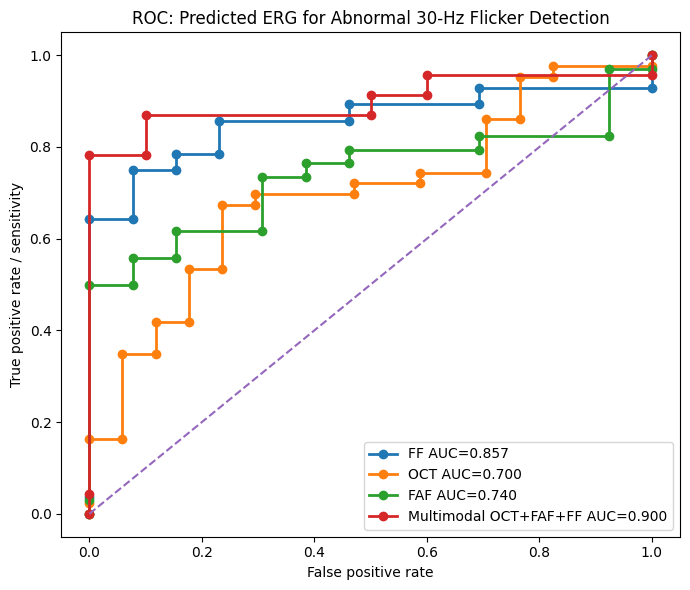

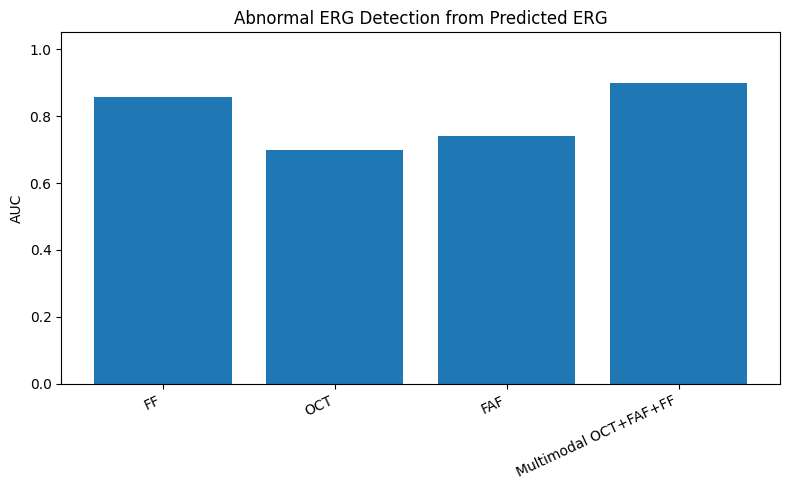


Saved files:
/content/drive/MyDrive/CORD project/STEP11B_predicted_ERG_abnormality_classification.csv
/content/drive/MyDrive/CORD project/STEP11B_youden_thresholds.csv
/content/drive/MyDrive/CORD project/STEP11B_predicted_ERG_abnormality_classification_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11B_youden_thresholds_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11B_ROC_predicted_ERG_abnormality.png
/content/drive/MyDrive/CORD project/STEP11B_AUC_bar_abnormal_ERG_detection.png


In [4]:
# ============================================================
# STEP 11B - ERG ABNORMALITY CLASSIFICATION FROM PREDICTED ERG
# Actual ERG <=50 µV = abnormal
# Predicted ERG <=50 µV = predicted abnormal
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    balanced_accuracy_score
)

from statsmodels.stats.proportion import proportion_confint

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

RANDOM_SEED = 42
N_BOOT = 5000
ERG_CUTOFF = 50.0

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# Helper functions
# ============================================================

def wilson_ci(count, nobs, alpha=0.05):
    if nobs == 0:
        return np.nan, np.nan
    return proportion_confint(
        count=count,
        nobs=nobs,
        alpha=alpha,
        method="wilson"
    )


def bootstrap_ci(values, ci=95):
    values = np.array(values)
    values = values[~np.isnan(values)]
    lower = np.percentile(values, (100 - ci) / 2)
    upper = np.percentile(values, 100 - (100 - ci) / 2)
    return lower, upper


def safe_auc(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def diagnostic_metrics(y_true_abnormal, y_pred_abnormal, abnormal_score):
    """
    y_true_abnormal:
        1 = actual abnormal ERG
        0 = actual preserved ERG

    y_pred_abnormal:
        1 = predicted abnormal ERG
        0 = predicted preserved ERG

    abnormal_score:
        continuous score where higher = more likely abnormal
        Here we use -Predicted_ERG30Hz because lower ERG means more abnormal.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true_abnormal,
        y_pred_abnormal,
        labels=[0, 1]
    ).ravel()

    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total if total > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    balanced_acc = balanced_accuracy_score(y_true_abnormal, y_pred_abnormal)

    auc_value = safe_auc(y_true_abnormal, abnormal_score)

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Balanced_Accuracy": balanced_acc,
        "AUC": auc_value
    }


def get_youden_threshold(y_true_abnormal, predicted_erg):
    """
    Finds optimal predicted ERG threshold for abnormality using Youden index.

    Since lower ERG = more abnormal:
    abnormal_score = -predicted_erg

    ROC threshold is applied to abnormal_score.
    Converted threshold:
    predicted abnormal if predicted ERG <= best_predicted_erg_threshold
    """

    abnormal_score = -predicted_erg

    fpr, tpr, thresholds = roc_curve(y_true_abnormal, abnormal_score)

    youden = tpr - fpr
    best_idx = np.argmax(youden)

    best_score_threshold = thresholds[best_idx]
    best_predicted_erg_threshold = -best_score_threshold

    return {
        "Best_predicted_ERG_threshold": best_predicted_erg_threshold,
        "Best_sensitivity": tpr[best_idx],
        "Best_specificity": 1 - fpr[best_idx],
        "Best_Youden_index": youden[best_idx],
        "FPR": fpr,
        "TPR": tpr,
        "Score_thresholds": thresholds
    }


# ============================================================
# Load regression prediction files
# ============================================================

regression_files = {
    "FF": PROJECT_ROOT + "/FF_ERG_regression_predictions.csv",
    "OCT": PROJECT_ROOT + "/OCT_ERG_regression_predictions.csv",
    "FAF": PROJECT_ROOT + "/FAF_ERG_regression_predictions.csv",
    "Multimodal OCT+FAF+FF": PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv",
}

rows = []
youden_rows = []
roc_data = {}

for model_name, path in regression_files.items():

    df = pd.read_csv(path)

    y_actual = df["ERG30Hz"].values.astype(float)
    y_predicted = df["Predicted_ERG30Hz"].values.astype(float)

    # Actual abnormality
    y_true_abnormal = (y_actual <= ERG_CUTOFF).astype(int)

    # Predicted abnormality using fixed clinical threshold
    y_pred_abnormal_fixed = (y_predicted <= ERG_CUTOFF).astype(int)

    # Continuous abnormality score for ROC
    # Higher score = more abnormal
    abnormal_score = -y_predicted

    base = diagnostic_metrics(
        y_true_abnormal=y_true_abnormal,
        y_pred_abnormal=y_pred_abnormal_fixed,
        abnormal_score=abnormal_score
    )

    # Wilson CI for fixed-threshold diagnostic metrics
    acc_low, acc_high = wilson_ci(
        count=base["TP"] + base["TN"],
        nobs=base["TP"] + base["TN"] + base["FP"] + base["FN"]
    )

    sens_low, sens_high = wilson_ci(
        count=base["TP"],
        nobs=base["TP"] + base["FN"]
    )

    spec_low, spec_high = wilson_ci(
        count=base["TN"],
        nobs=base["TN"] + base["FP"]
    )

    ppv_low, ppv_high = wilson_ci(
        count=base["TP"],
        nobs=base["TP"] + base["FP"]
    )

    npv_low, npv_high = wilson_ci(
        count=base["TN"],
        nobs=base["TN"] + base["FN"]
    )

    # Bootstrap AUC CI
    boot_auc = []

    for i in range(N_BOOT):
        idx = rng.integers(0, len(df), len(df))
        auc_i = safe_auc(y_true_abnormal[idx], abnormal_score[idx])
        boot_auc.append(auc_i)

    auc_low, auc_high = bootstrap_ci(boot_auc)

    # Youden threshold
    youden_result = get_youden_threshold(y_true_abnormal, y_predicted)

    best_threshold = youden_result["Best_predicted_ERG_threshold"]
    y_pred_abnormal_youden = (y_predicted <= best_threshold).astype(int)

    youden_metrics = diagnostic_metrics(
        y_true_abnormal=y_true_abnormal,
        y_pred_abnormal=y_pred_abnormal_youden,
        abnormal_score=abnormal_score
    )

    # Store ROC data
    fpr, tpr, thresholds = roc_curve(y_true_abnormal, abnormal_score)

    roc_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": base["AUC"]
    }

    rows.append({
        "Model": model_name,
        "N": len(df),
        "Actual_Abnormal_N": int(np.sum(y_true_abnormal == 1)),
        "Actual_Preserved_N": int(np.sum(y_true_abnormal == 0)),

        "Fixed_Cutoff_Predicted_ERG_uV": ERG_CUTOFF,

        "Accuracy": base["Accuracy"],
        "Accuracy_95CI_low": acc_low,
        "Accuracy_95CI_high": acc_high,

        "Sensitivity": base["Sensitivity"],
        "Sensitivity_95CI_low": sens_low,
        "Sensitivity_95CI_high": sens_high,

        "Specificity": base["Specificity"],
        "Specificity_95CI_low": spec_low,
        "Specificity_95CI_high": spec_high,

        "PPV": base["PPV"],
        "PPV_95CI_low": ppv_low,
        "PPV_95CI_high": ppv_high,

        "NPV": base["NPV"],
        "NPV_95CI_low": npv_low,
        "NPV_95CI_high": npv_high,

        "Balanced_Accuracy": base["Balanced_Accuracy"],

        "AUC": base["AUC"],
        "AUC_95CI_low": auc_low,
        "AUC_95CI_high": auc_high,

        "TP": base["TP"],
        "TN": base["TN"],
        "FP": base["FP"],
        "FN": base["FN"],
    })

    youden_rows.append({
        "Model": model_name,
        "N": len(df),

        "Youden_Best_Predicted_ERG_Threshold_uV": best_threshold,
        "Youden_Index": youden_result["Best_Youden_index"],

        "Sensitivity_at_Youden": youden_metrics["Sensitivity"],
        "Specificity_at_Youden": youden_metrics["Specificity"],
        "Accuracy_at_Youden": youden_metrics["Accuracy"],
        "Balanced_Accuracy_at_Youden": youden_metrics["Balanced_Accuracy"],

        "TP_at_Youden": youden_metrics["TP"],
        "TN_at_Youden": youden_metrics["TN"],
        "FP_at_Youden": youden_metrics["FP"],
        "FN_at_Youden": youden_metrics["FN"],
    })

# ============================================================
# Output tables
# ============================================================

erg_abnormality_results = pd.DataFrame(rows)
youden_results = pd.DataFrame(youden_rows)

print("===== ERG abnormality classification using fixed 50 µV cutoff =====")
display(erg_abnormality_results)

print("\n===== Optimized predicted ERG threshold using Youden index =====")
display(youden_results)

# Rounded poster tables
erg_abnormality_poster = erg_abnormality_results.copy()
youden_poster = youden_results.copy()

for col in erg_abnormality_poster.columns:
    if erg_abnormality_poster[col].dtype != "object":
        erg_abnormality_poster[col] = erg_abnormality_poster[col].round(3)

for col in youden_poster.columns:
    if youden_poster[col].dtype != "object":
        youden_poster[col] = youden_poster[col].round(3)

print("\n===== Poster-friendly ERG abnormality table =====")
display(erg_abnormality_poster)

print("\n===== Poster-friendly Youden threshold table =====")
display(youden_poster)

# ============================================================
# Save tables
# ============================================================

erg_abnormality_results.to_csv(
    PROJECT_ROOT + "/STEP11B_predicted_ERG_abnormality_classification.csv",
    index=False
)

youden_results.to_csv(
    PROJECT_ROOT + "/STEP11B_youden_thresholds.csv",
    index=False
)

erg_abnormality_poster.to_csv(
    PROJECT_ROOT + "/STEP11B_predicted_ERG_abnormality_classification_poster_rounded.csv",
    index=False
)

youden_poster.to_csv(
    PROJECT_ROOT + "/STEP11B_youden_thresholds_poster_rounded.csv",
    index=False
)

# ============================================================
# Plot ROC curves for abnormal ERG detection
# ============================================================

plt.figure(figsize=(7, 6))

for model_name, data in roc_data.items():
    plt.plot(
        data["fpr"],
        data["tpr"],
        marker="o",
        linewidth=2,
        label=f"{model_name} AUC={data['auc']:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / sensitivity")
plt.title("ROC: Predicted ERG for Abnormal 30-Hz Flicker Detection")
plt.legend()
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT + "/STEP11B_ROC_predicted_ERG_abnormality.png",
    dpi=300
)
plt.show()

# ============================================================
# Plot confusion-matrix-style summary
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(
    erg_abnormality_poster["Model"],
    erg_abnormality_poster["AUC"]
)
plt.ylabel("AUC")
plt.title("Abnormal ERG Detection from Predicted ERG")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT + "/STEP11B_AUC_bar_abnormal_ERG_detection.png",
    dpi=300
)
plt.show()

print("\nSaved files:")
print(PROJECT_ROOT + "/STEP11B_predicted_ERG_abnormality_classification.csv")
print(PROJECT_ROOT + "/STEP11B_youden_thresholds.csv")
print(PROJECT_ROOT + "/STEP11B_predicted_ERG_abnormality_classification_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11B_youden_thresholds_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11B_ROC_predicted_ERG_abnormality.png")
print(PROJECT_ROOT + "/STEP11B_AUC_bar_abnormal_ERG_detection.png")

===== Bland-Altman summary =====


,Model,N,Mean_actual_ERG,Mean_predicted_ERG,Bias_predicted_minus_actual,Bias_95CI_low,Bias_95CI_high,SD_difference,Lower_LoA,Lower_LoA_95CI_low,...,Proportional_bias_slope,Proportional_bias_intercept,Proportional_bias_r,Proportional_bias_p,Bias_boot_95CI_low,Bias_boot_95CI_high,Lower_LoA_boot_95CI_low,Lower_LoA_boot_95CI_high,Upper_LoA_boot_95CI_low,Upper_LoA_boot_95CI_high
0,FF,41,31.497561,32.330506,0.832946,-7.002920,8.668811,24.825407,-47.824852,-61.326255,...,-0.361834,12.380535,-0.411314,0.007548,-6.873389,8.196369,-62.465246,-31.715111,35.443654,61.098386
1,OCT,60,31.450000,31.444985,-0.005015,-6.786260,6.776230,26.250584,-51.456161,-63.109955,...,-0.658535,20.704252,-0.539112,0.000009,-6.753356,6.598614,-63.135471,-38.104748,41.924398,59.734225
2,FAF,47,28.978723,28.830472,-0.148252,-6.266833,5.970330,20.839074,-40.992836,-51.524187,...,-0.413617,11.807172,-0.399324,0.005426,-5.923911,5.673255,-49.794851,-30.747607,30.398277,50.356789
3,Multimodal OCT+FAF+FF,33,28.727273,29.205483,0.478210,-4.936606,5.893025,15.270871,-29.452698,-38.801413,...,-0.347250,10.536778,-0.520986,0.001879,-4.836222,5.409611,-39.528495,-19.222116,21.067538,37.942935



===== Poster-friendly Bland-Altman table =====


,Model,N,Mean_actual_ERG,Mean_predicted_ERG,Bias_predicted_minus_actual,Bias_95CI_low,Bias_95CI_high,SD_difference,Lower_LoA,Lower_LoA_95CI_low,...,Proportional_bias_slope,Proportional_bias_intercept,Proportional_bias_r,Proportional_bias_p,Bias_boot_95CI_low,Bias_boot_95CI_high,Lower_LoA_boot_95CI_low,Lower_LoA_boot_95CI_high,Upper_LoA_boot_95CI_low,Upper_LoA_boot_95CI_high
0,FF,41,31.498,32.331,0.833,-7.003,8.669,24.825,-47.825,-61.326,...,-0.362,12.381,-0.411,0.008,-6.873,8.196,-62.465,-31.715,35.444,61.098
1,OCT,60,31.450,31.445,-0.005,-6.786,6.776,26.251,-51.456,-63.110,...,-0.659,20.704,-0.539,0.000,-6.753,6.599,-63.135,-38.105,41.924,59.734
2,FAF,47,28.979,28.830,-0.148,-6.267,5.970,20.839,-40.993,-51.524,...,-0.414,11.807,-0.399,0.005,-5.924,5.673,-49.795,-30.748,30.398,50.357
3,Multimodal OCT+FAF+FF,33,28.727,29.205,0.478,-4.937,5.893,15.271,-29.453,-38.801,...,-0.347,10.537,-0.521,0.002,-4.836,5.410,-39.528,-19.222,21.068,37.943


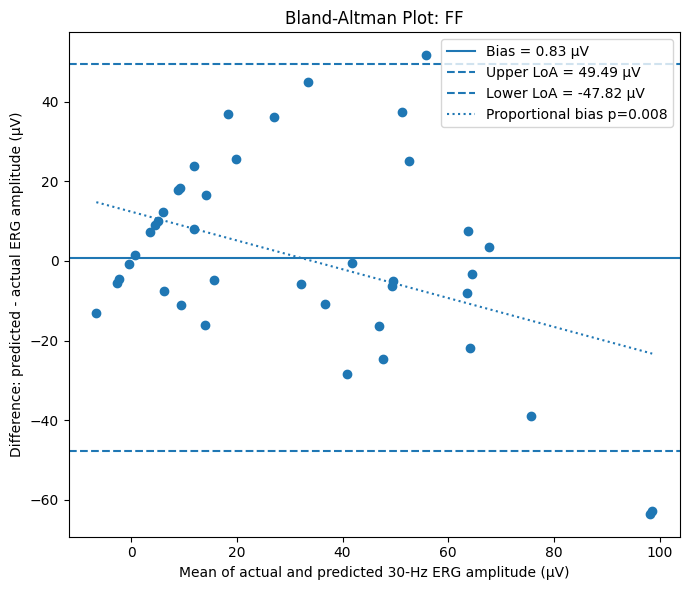

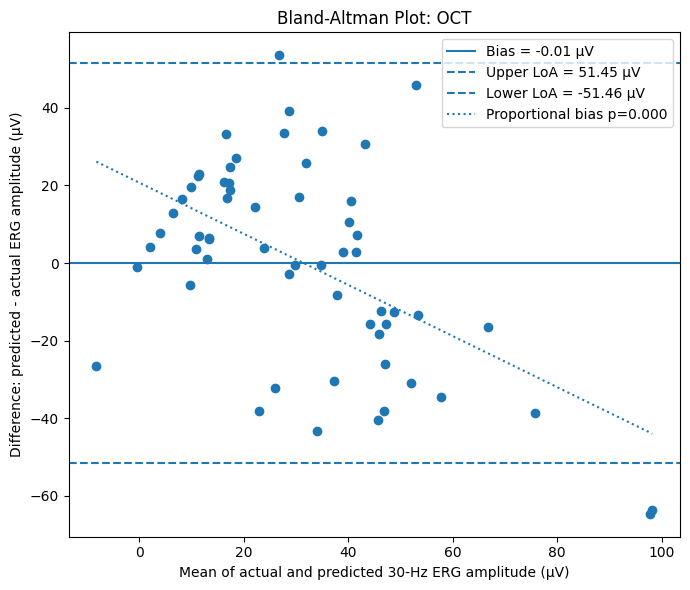

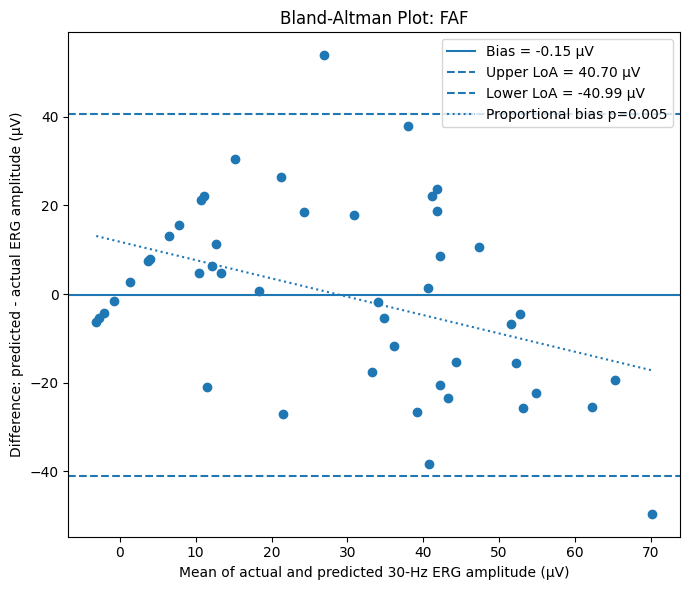

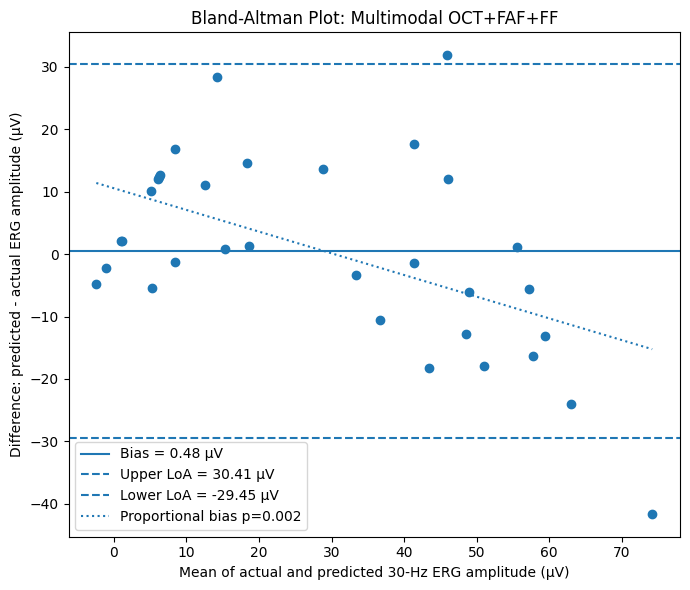

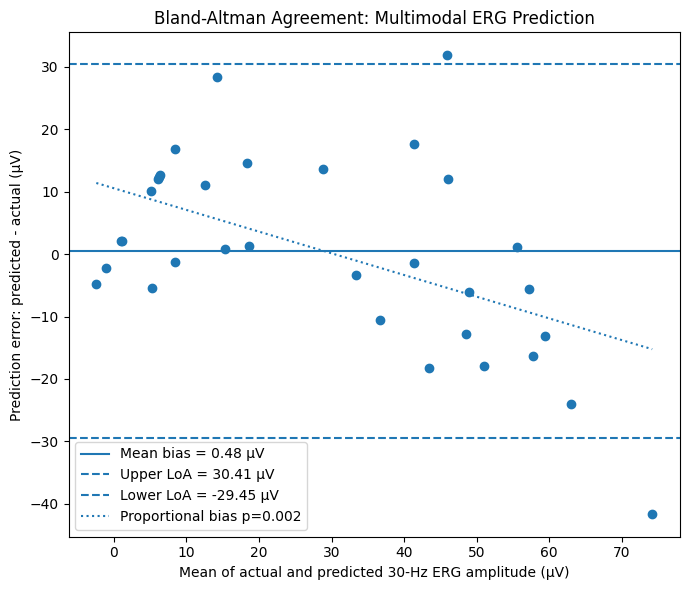


===== Error direction summary =====


,Model,N,Overestimated_N,Underestimated_N,Exact_N,Median_error,Mean_error,Mean_absolute_error,Max_overestimation,Max_underestimation
0,FF,41,19,22,0,-0.648252,0.832946,18.348758,51.664076,-63.523169
1,OCT,60,34,26,0,3.831921,-0.005015,21.009173,53.510872,-64.592777
2,FAF,47,24,23,0,0.643503,-0.148252,16.661983,53.891156,-49.581848
3,Multimodal OCT+FAF+FF,33,17,16,0,0.738157,0.478210,11.677606,31.836100,-41.593012



Saved files:
/content/drive/MyDrive/CORD project/STEP11C_bland_altman_summary.csv
/content/drive/MyDrive/CORD project/STEP11C_bland_altman_summary_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11C_MAIN_Bland_Altman_Multimodal.png
/content/drive/MyDrive/CORD project/STEP11C_error_direction_summary.csv


In [6]:
# ============================================================
# STEP 11C - BLAND-ALTMAN ANALYSIS
# Agreement between measured ERG and predicted ERG
# Difference = Predicted ERG - Actual ERG
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, t

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

RANDOM_SEED = 42
N_BOOT = 5000

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# Helper functions
# ============================================================

def bland_altman_stats(actual, predicted):
    """
    Bland-Altman statistics.

    mean_values = average of actual and predicted ERG
    difference = predicted - actual

    Bias:
        Mean difference.

    Limits of agreement:
        Bias ± 1.96 SD of differences.
    """

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mean_values = (actual + predicted) / 2
    diff = predicted - actual

    n = len(diff)
    bias = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)

    loa_lower = bias - 1.96 * sd_diff
    loa_upper = bias + 1.96 * sd_diff

    # Parametric 95% CI for bias
    t_crit = t.ppf(0.975, df=n - 1)
    bias_se = sd_diff / np.sqrt(n)
    bias_ci_low = bias - t_crit * bias_se
    bias_ci_high = bias + t_crit * bias_se

    # Approximate 95% CI for limits of agreement
    # Bland-Altman approximate SE for each LoA
    loa_se = sd_diff * np.sqrt((1 / n) + ((1.96 ** 2) / (2 * (n - 1))))

    loa_lower_ci_low = loa_lower - t_crit * loa_se
    loa_lower_ci_high = loa_lower + t_crit * loa_se

    loa_upper_ci_low = loa_upper - t_crit * loa_se
    loa_upper_ci_high = loa_upper + t_crit * loa_se

    # Proportional bias test
    # Tests whether error changes with ERG magnitude
    reg = linregress(mean_values, diff)

    return {
        "N": n,
        "Mean_actual_ERG": np.mean(actual),
        "Mean_predicted_ERG": np.mean(predicted),
        "Bias_predicted_minus_actual": bias,
        "Bias_95CI_low": bias_ci_low,
        "Bias_95CI_high": bias_ci_high,
        "SD_difference": sd_diff,
        "Lower_LoA": loa_lower,
        "Lower_LoA_95CI_low": loa_lower_ci_low,
        "Lower_LoA_95CI_high": loa_lower_ci_high,
        "Upper_LoA": loa_upper,
        "Upper_LoA_95CI_low": loa_upper_ci_low,
        "Upper_LoA_95CI_high": loa_upper_ci_high,
        "Proportional_bias_slope": reg.slope,
        "Proportional_bias_intercept": reg.intercept,
        "Proportional_bias_r": reg.rvalue,
        "Proportional_bias_p": reg.pvalue
    }


def bootstrap_ba_ci(actual, predicted, n_boot=5000):
    """
    Bootstrap confidence intervals for bias and limits of agreement.
    """

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    boot_bias = []
    boot_lower_loa = []
    boot_upper_loa = []

    n = len(actual)

    for i in range(n_boot):
        idx = rng.integers(0, n, n)

        diff_i = predicted[idx] - actual[idx]

        bias_i = np.mean(diff_i)
        sd_i = np.std(diff_i, ddof=1)

        boot_bias.append(bias_i)
        boot_lower_loa.append(bias_i - 1.96 * sd_i)
        boot_upper_loa.append(bias_i + 1.96 * sd_i)

    return {
        "Bias_boot_95CI_low": np.percentile(boot_bias, 2.5),
        "Bias_boot_95CI_high": np.percentile(boot_bias, 97.5),
        "Lower_LoA_boot_95CI_low": np.percentile(boot_lower_loa, 2.5),
        "Lower_LoA_boot_95CI_high": np.percentile(boot_lower_loa, 97.5),
        "Upper_LoA_boot_95CI_low": np.percentile(boot_upper_loa, 2.5),
        "Upper_LoA_boot_95CI_high": np.percentile(boot_upper_loa, 97.5),
    }


# ============================================================
# Load regression files
# ============================================================

regression_files = {
    "FF": PROJECT_ROOT + "/FF_ERG_regression_predictions.csv",
    "OCT": PROJECT_ROOT + "/OCT_ERG_regression_predictions.csv",
    "FAF": PROJECT_ROOT + "/FAF_ERG_regression_predictions.csv",
    "Multimodal OCT+FAF+FF": PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv",
}

ba_rows = []

for model_name, path in regression_files.items():

    df = pd.read_csv(path)

    actual = df["ERG30Hz"].values.astype(float)
    predicted = df["Predicted_ERG30Hz"].values.astype(float)

    stats = bland_altman_stats(actual, predicted)
    boot = bootstrap_ba_ci(actual, predicted, n_boot=N_BOOT)

    row = {"Model": model_name}
    row.update(stats)
    row.update(boot)

    ba_rows.append(row)

ba_summary = pd.DataFrame(ba_rows)

print("===== Bland-Altman summary =====")
display(ba_summary)

# Simple rounded table
ba_poster = ba_summary.copy()

for col in ba_poster.columns:
    if ba_poster[col].dtype != "object":
        ba_poster[col] = ba_poster[col].round(3)

print("\n===== Poster-friendly Bland-Altman table =====")
display(ba_poster)

# Save tables
ba_summary.to_csv(
    PROJECT_ROOT + "/STEP11C_bland_altman_summary.csv",
    index=False
)

ba_poster.to_csv(
    PROJECT_ROOT + "/STEP11C_bland_altman_summary_poster_rounded.csv",
    index=False
)

# ============================================================
# Individual Bland-Altman plots
# ============================================================

for model_name, path in regression_files.items():

    df = pd.read_csv(path)

    actual = df["ERG30Hz"].values.astype(float)
    predicted = df["Predicted_ERG30Hz"].values.astype(float)

    mean_values = (actual + predicted) / 2
    diff = predicted - actual

    stats = bland_altman_stats(actual, predicted)

    plt.figure(figsize=(7, 6))

    plt.scatter(mean_values, diff)

    plt.axhline(
        stats["Bias_predicted_minus_actual"],
        linestyle="-",
        label=f"Bias = {stats['Bias_predicted_minus_actual']:.2f} µV"
    )

    plt.axhline(
        stats["Upper_LoA"],
        linestyle="--",
        label=f"Upper LoA = {stats['Upper_LoA']:.2f} µV"
    )

    plt.axhline(
        stats["Lower_LoA"],
        linestyle="--",
        label=f"Lower LoA = {stats['Lower_LoA']:.2f} µV"
    )

    # Proportional bias regression line
    reg = linregress(mean_values, diff)
    x_line = np.linspace(mean_values.min(), mean_values.max(), 100)
    y_line = reg.intercept + reg.slope * x_line

    plt.plot(
        x_line,
        y_line,
        linestyle=":",
        label=f"Proportional bias p={reg.pvalue:.3f}"
    )

    plt.xlabel("Mean of actual and predicted 30-Hz ERG amplitude (µV)")
    plt.ylabel("Difference: predicted - actual ERG amplitude (µV)")
    plt.title(f"Bland-Altman Plot: {model_name}")
    plt.legend()
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("+", "_").replace("/", "_")
    out_path = PROJECT_ROOT + f"/STEP11C_Bland_Altman_{safe_name}.png"

    plt.savefig(out_path, dpi=300)
    plt.show()

# ============================================================
# Main plot: multimodal only
# ============================================================

multi = pd.read_csv(PROJECT_ROOT + "/MULTIMODAL_ERG_regression_predictions.csv")

actual = multi["ERG30Hz"].values.astype(float)
predicted = multi["Predicted_ERG30Hz"].values.astype(float)

mean_values = (actual + predicted) / 2
diff = predicted - actual

stats = bland_altman_stats(actual, predicted)
reg = linregress(mean_values, diff)

plt.figure(figsize=(7, 6))

plt.scatter(mean_values, diff)

plt.axhline(
    stats["Bias_predicted_minus_actual"],
    linestyle="-",
    label=f"Mean bias = {stats['Bias_predicted_minus_actual']:.2f} µV"
)

plt.axhline(
    stats["Upper_LoA"],
    linestyle="--",
    label=f"Upper LoA = {stats['Upper_LoA']:.2f} µV"
)

plt.axhline(
    stats["Lower_LoA"],
    linestyle="--",
    label=f"Lower LoA = {stats['Lower_LoA']:.2f} µV"
)

x_line = np.linspace(mean_values.min(), mean_values.max(), 100)
y_line = reg.intercept + reg.slope * x_line

plt.plot(
    x_line,
    y_line,
    linestyle=":",
    label=f"Proportional bias p={reg.pvalue:.3f}"
)

plt.xlabel("Mean of actual and predicted 30-Hz ERG amplitude (µV)")
plt.ylabel("Prediction error: predicted - actual (µV)")
plt.title("Bland-Altman Agreement: Multimodal ERG Prediction")
plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT + "/STEP11C_MAIN_Bland_Altman_Multimodal.png",
    dpi=300
)

plt.show()

# ============================================================
# Error direction table
# ============================================================

error_rows = []

for model_name, path in regression_files.items():

    df = pd.read_csv(path)

    actual = df["ERG30Hz"].values.astype(float)
    predicted = df["Predicted_ERG30Hz"].values.astype(float)

    diff = predicted - actual

    error_rows.append({
        "Model": model_name,
        "N": len(df),
        "Overestimated_N": int(np.sum(diff > 0)),
        "Underestimated_N": int(np.sum(diff < 0)),
        "Exact_N": int(np.sum(diff == 0)),
        "Median_error": np.median(diff),
        "Mean_error": np.mean(diff),
        "Mean_absolute_error": np.mean(np.abs(diff)),
        "Max_overestimation": np.max(diff),
        "Max_underestimation": np.min(diff)
    })

error_direction = pd.DataFrame(error_rows)

print("\n===== Error direction summary =====")
display(error_direction)

error_direction.to_csv(
    PROJECT_ROOT + "/STEP11C_error_direction_summary.csv",
    index=False
)

print("\nSaved files:")
print(PROJECT_ROOT + "/STEP11C_bland_altman_summary.csv")
print(PROJECT_ROOT + "/STEP11C_bland_altman_summary_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11C_MAIN_Bland_Altman_Multimodal.png")
print(PROJECT_ROOT + "/STEP11C_error_direction_summary.csv")

Common same-case comparison cases: 33
[14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63]

Same-33 table:


,CaseID,ERG30Hz,OCT_path,FAF_path,FF_path,OCT_file,FAF_file,FF_file
0,14,9.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 14 - OCT.png,Case 14 - FAF.png,Case 14 - FF.png
1,15,11.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 15 - OCT.png,Case 15 - FAF.png,Case 15 - FF.png
2,22,22.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 22 - OCT.png,Case 22 - FAF.png,Case 22 - FF.png
3,23,18.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 23 - OCT.png,Case 23 - FAF.png,Case 23 - FF.png
4,24,15.0,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,/content/drive/MyDrive/CORD project/Image data...,Case 24 - OCT.png,Case 24 - FAF.png,Case 24 - FF.png


N: 33
ERG range: 0.0 - 95.0

Image tensors:
OCT: (33, 224, 224, 3)
FAF: (33, 224, 224, 3)
FF: (33, 224, 224, 3)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 907ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step

Feature matrices:
OCT: (33, 1280)
FAF: (33, 1280)
FF: (33, 1280)
Multimodal: (33, 3840)

===== Same-33-case regression comparison =====


,Model,N,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,RMSE_95CI_low,RMSE_95CI_high,R2,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_p,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_p,Spearman_r_95CI_low,Spearman_r_95CI_high
0,OCT-only same 33,33,18.895955,13.983049,24.483319,24.219053,17.829112,30.245689,0.209809,-0.193512,0.466575,0.475014,5.215669e-03,0.186799,0.705435,0.471444,5.613970e-03,0.091095,0.738585
1,FAF-only same 33,33,13.855168,9.574335,19.038642,19.678835,12.846941,26.244322,0.478305,0.165752,0.728072,0.694719,7.271825e-06,0.494204,0.861367,0.714880,2.952909e-06,0.459011,0.861169
2,FF-only same 33,33,16.159957,12.492186,20.166514,19.667562,15.446051,23.711675,0.478902,0.129897,0.650297,0.695880,6.917585e-06,0.556684,0.835017,0.755565,3.715869e-07,0.593035,0.851563
3,Multimodal OCT+FAF+FF same 33,33,11.677606,8.650324,15.187132,15.045316,11.120208,18.966301,0.695056,0.527178,0.801425,0.842270,7.993056e-10,0.750955,0.921628,0.844226,6.682380e-10,0.708087,0.913476



===== Poster-friendly same-33-case comparison =====


,Model,N,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,RMSE_95CI_low,RMSE_95CI_high,R2,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_p,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_p,Spearman_r_95CI_low,Spearman_r_95CI_high
0,OCT-only same 33,33,18.896,13.983,24.483,24.219,17.829,30.246,0.210,-0.194,0.467,0.475,0.005,0.187,0.705,0.471,0.006,0.091,0.739
1,FAF-only same 33,33,13.855,9.574,19.039,19.679,12.847,26.244,0.478,0.166,0.728,0.695,0.000,0.494,0.861,0.715,0.000,0.459,0.861
2,FF-only same 33,33,16.160,12.492,20.167,19.668,15.446,23.712,0.479,0.130,0.650,0.696,0.000,0.557,0.835,0.756,0.000,0.593,0.852
3,Multimodal OCT+FAF+FF same 33,33,11.678,8.650,15.187,15.045,11.120,18.966,0.695,0.527,0.801,0.842,0.000,0.751,0.922,0.844,0.000,0.708,0.913



===== Original full-N regression summary =====


,Model,N,MAE_uV,RMSE_uV,R2,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,FF,41,18.348758,24.534932,0.501853,0.709165,2.105469e-07,0.750665,1.585104e-08
1,OCT,60,21.009173,26.030911,0.265537,0.520398,2.025819e-05,0.488531,7.490627e-05
2,FAF,47,16.661983,20.616723,0.362052,0.610393,5.223522e-06,0.600060,8.270244e-06
3,Multimodal OCT+FAF+FF,33,11.677606,15.045316,0.695056,0.842270,7.993056e-10,0.844226,6.682380e-10


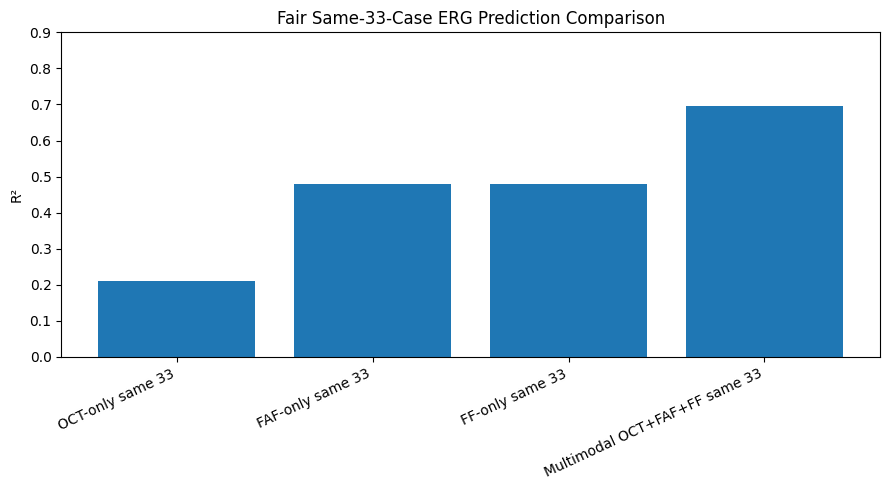

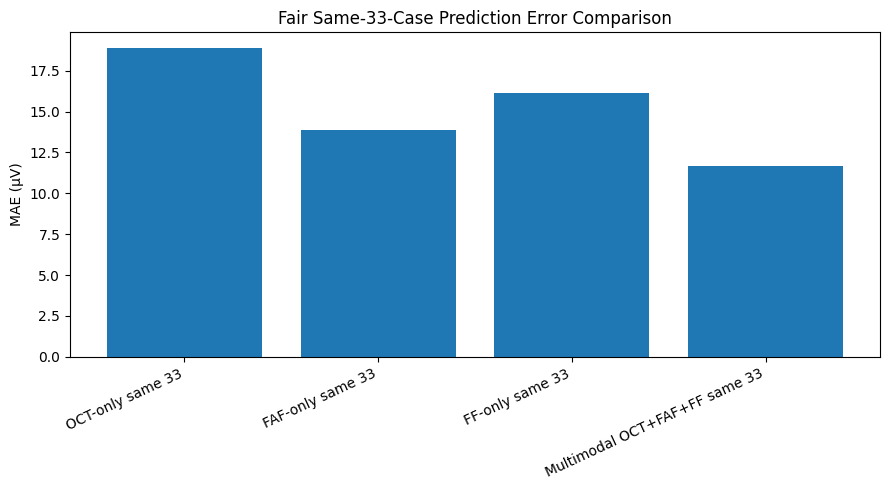

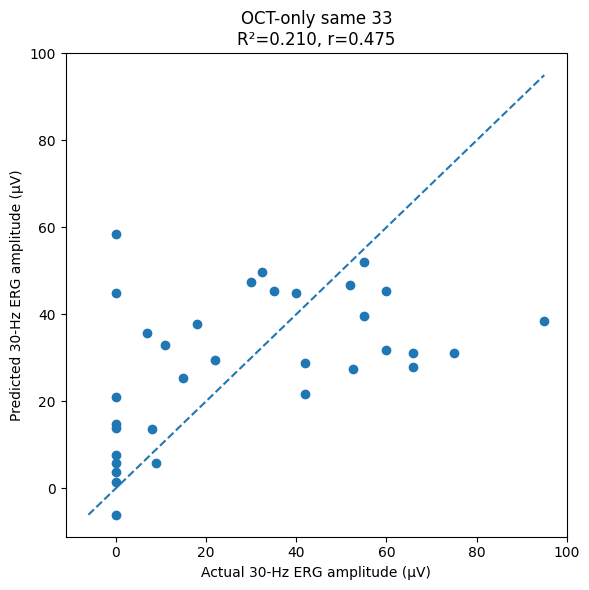

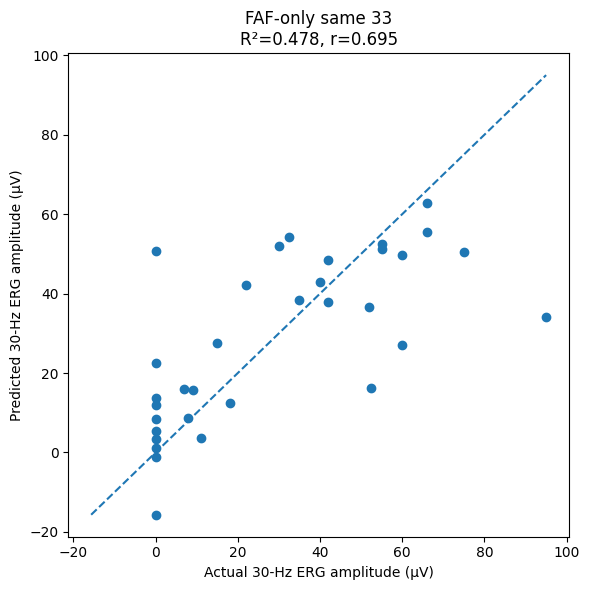

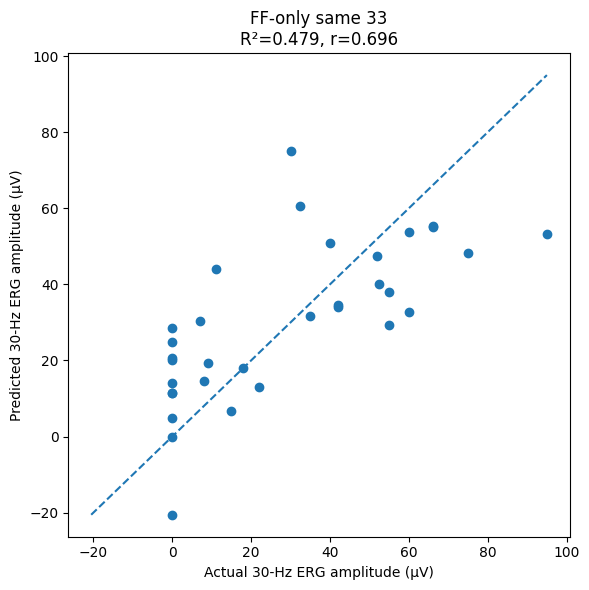

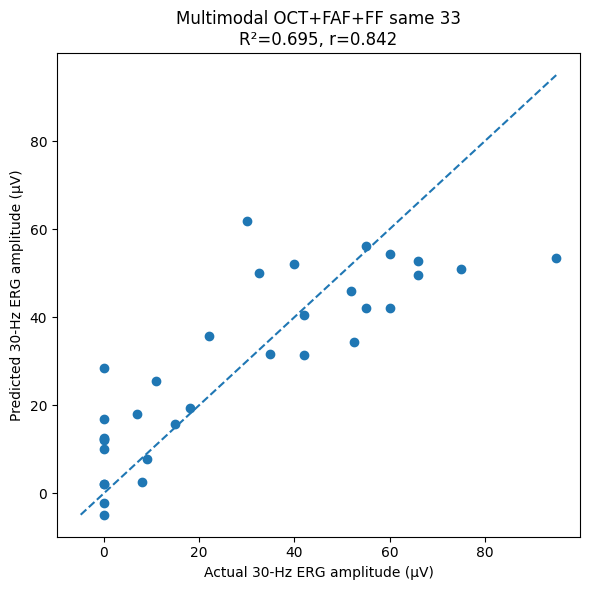


===== Multimodal improvement over best single modality, same 33 cases =====


,Best_single_modality_R2,Multimodal_R2,Absolute_R2_improvement,Best_single_modality_MAE,Multimodal_MAE,Absolute_MAE_reduction_uV,Percent_MAE_reduction
0,0.478902,0.695056,0.216153,13.855168,11.677606,2.177563,15.71661



Saved files:
/content/drive/MyDrive/CORD project/STEP11D_same33_case_table.csv
/content/drive/MyDrive/CORD project/STEP11D_same33_regression_comparison.csv
/content/drive/MyDrive/CORD project/STEP11D_same33_regression_comparison_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11D_same33_all_model_predictions.csv
/content/drive/MyDrive/CORD project/STEP11D_same33_R2_comparison.png
/content/drive/MyDrive/CORD project/STEP11D_same33_MAE_comparison.png
/content/drive/MyDrive/CORD project/STEP11D_multimodal_improvement_over_best_single_same33.csv


In [7]:
# ============================================================
# STEP 11D - FAIR SAME-33-CASE COMPARISON
# OCT-only vs FAF-only vs FF-only vs Multimodal
# Same 33 cases for all models
# EfficientNetB0 feature extraction + Ridge regression + LOO CV
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

IMG_SIZE = 224
RANDOM_SEED = 42
N_BOOT = 5000

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# Helper functions
# ============================================================

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img.numpy()


def load_image_stack(paths):
    return np.stack([load_img_array(p) for p in paths])


def regression_metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)

    pearson = pearsonr(y, pred)
    spearman = spearmanr(y, pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pearson_r": pearson.statistic,
        "Pearson_p": pearson.pvalue,
        "Spearman_r": spearman.statistic,
        "Spearman_p": spearman.pvalue
    }


def bootstrap_ci(values, ci=95):
    values = np.array(values)
    values = values[~np.isnan(values)]
    low = np.percentile(values, (100 - ci) / 2)
    high = np.percentile(values, 100 - (100 - ci) / 2)
    return low, high


def bootstrap_metric_ci(y, pred, n_boot=5000):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    boot_mae = []
    boot_rmse = []
    boot_r2 = []
    boot_pearson = []
    boot_spearman = []

    n = len(y)

    for i in range(n_boot):
        idx = rng.integers(0, n, n)

        y_i = y[idx]
        pred_i = pred[idx]

        try:
            m = regression_metrics(y_i, pred_i)
            boot_mae.append(m["MAE"])
            boot_rmse.append(m["RMSE"])
            boot_r2.append(m["R2"])
            boot_pearson.append(m["Pearson_r"])
            boot_spearman.append(m["Spearman_r"])
        except Exception:
            continue

    return {
        "MAE_95CI_low": bootstrap_ci(boot_mae)[0],
        "MAE_95CI_high": bootstrap_ci(boot_mae)[1],

        "RMSE_95CI_low": bootstrap_ci(boot_rmse)[0],
        "RMSE_95CI_high": bootstrap_ci(boot_rmse)[1],

        "R2_95CI_low": bootstrap_ci(boot_r2)[0],
        "R2_95CI_high": bootstrap_ci(boot_r2)[1],

        "Pearson_r_95CI_low": bootstrap_ci(boot_pearson)[0],
        "Pearson_r_95CI_high": bootstrap_ci(boot_pearson)[1],

        "Spearman_r_95CI_low": bootstrap_ci(boot_spearman)[0],
        "Spearman_r_95CI_high": bootstrap_ci(boot_spearman)[1],
    }


def run_ridge_loo(features, y):
    alphas = np.logspace(-3, 3, 30)

    model = RidgeCV(alphas=alphas)

    loo = LeaveOneOut()
    pred = cross_val_predict(model, features, y, cv=loo)

    model.fit(features, y)

    return pred, model


# ============================================================
# 1. Load metadata and identify same 33 multimodal cases
# ============================================================

df = pd.read_csv(META_PATH)

cord = df[
    (df["Split"] == "Test") &
    (df["Label"] == "CORD") &
    (df["ERG30Hz"].notna()) &
    (df["CaseID"].notna())
].copy()

cord["CaseID"] = cord["CaseID"].astype(int)

case_sets = {}

for modality in ["OCT", "FAF", "FF"]:
    case_sets[modality] = set(
        cord[cord["Modality"] == modality]["CaseID"].astype(int)
    )

common_cases = sorted(
    case_sets["OCT"] &
    case_sets["FAF"] &
    case_sets["FF"]
)

print("Common same-case comparison cases:", len(common_cases))
print(common_cases)

# ============================================================
# 2. Build same-case table
# ============================================================

rows = []

for case in common_cases:
    temp = cord[cord["CaseID"] == case]

    oct_row = temp[temp["Modality"] == "OCT"].iloc[0]
    faf_row = temp[temp["Modality"] == "FAF"].iloc[0]
    ff_row  = temp[temp["Modality"] == "FF"].iloc[0]

    rows.append({
        "CaseID": case,
        "ERG30Hz": float(oct_row["ERG30Hz"]),

        "OCT_path": oct_row["filepath"],
        "FAF_path": faf_row["filepath"],
        "FF_path": ff_row["filepath"],

        "OCT_file": oct_row["filename"],
        "FAF_file": faf_row["filename"],
        "FF_file": ff_row["filename"],
    })

same33 = pd.DataFrame(rows)

print("\nSame-33 table:")
display(same33.head())

print("N:", len(same33))
print("ERG range:", same33["ERG30Hz"].min(), "-", same33["ERG30Hz"].max())

same33.to_csv(
    PROJECT_ROOT + "/STEP11D_same33_case_table.csv",
    index=False
)

# ============================================================
# 3. Load image tensors
# ============================================================

X_oct = load_image_stack(same33["OCT_path"].values)
X_faf = load_image_stack(same33["FAF_path"].values)
X_ff  = load_image_stack(same33["FF_path"].values)

y = same33["ERG30Hz"].values.astype(float)

print("\nImage tensors:")
print("OCT:", X_oct.shape)
print("FAF:", X_faf.shape)
print("FF:", X_ff.shape)

# ============================================================
# 4. EfficientNetB0 feature extraction
# ============================================================

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

feat_oct = base.predict(X_oct, batch_size=8)
feat_faf = base.predict(X_faf, batch_size=8)
feat_ff  = base.predict(X_ff, batch_size=8)

feat_multi = np.concatenate([feat_oct, feat_faf, feat_ff], axis=1)

print("\nFeature matrices:")
print("OCT:", feat_oct.shape)
print("FAF:", feat_faf.shape)
print("FF:", feat_ff.shape)
print("Multimodal:", feat_multi.shape)

# ============================================================
# 5. Run same-33 regression models
# ============================================================

feature_sets = {
    "OCT-only same 33": feat_oct,
    "FAF-only same 33": feat_faf,
    "FF-only same 33": feat_ff,
    "Multimodal OCT+FAF+FF same 33": feat_multi,
}

summary_rows = []
prediction_tables = {}

for model_name, features in feature_sets.items():

    pred, fitted_model = run_ridge_loo(features, y)

    metrics = regression_metrics(y, pred)
    ci = bootstrap_metric_ci(y, pred, n_boot=N_BOOT)

    row = {
        "Model": model_name,
        "N": len(y),

        "MAE": metrics["MAE"],
        "MAE_95CI_low": ci["MAE_95CI_low"],
        "MAE_95CI_high": ci["MAE_95CI_high"],

        "RMSE": metrics["RMSE"],
        "RMSE_95CI_low": ci["RMSE_95CI_low"],
        "RMSE_95CI_high": ci["RMSE_95CI_high"],

        "R2": metrics["R2"],
        "R2_95CI_low": ci["R2_95CI_low"],
        "R2_95CI_high": ci["R2_95CI_high"],

        "Pearson_r": metrics["Pearson_r"],
        "Pearson_p": metrics["Pearson_p"],
        "Pearson_r_95CI_low": ci["Pearson_r_95CI_low"],
        "Pearson_r_95CI_high": ci["Pearson_r_95CI_high"],

        "Spearman_r": metrics["Spearman_r"],
        "Spearman_p": metrics["Spearman_p"],
        "Spearman_r_95CI_low": ci["Spearman_r_95CI_low"],
        "Spearman_r_95CI_high": ci["Spearman_r_95CI_high"],
    }

    summary_rows.append(row)

    pred_df = same33.copy()
    pred_df["Model"] = model_name
    pred_df["Predicted_ERG30Hz"] = pred
    pred_df["Prediction_Error"] = pred_df["Predicted_ERG30Hz"] - pred_df["ERG30Hz"]
    pred_df["Absolute_Error"] = abs(pred_df["Prediction_Error"])

    prediction_tables[model_name] = pred_df

same33_summary = pd.DataFrame(summary_rows)

print("\n===== Same-33-case regression comparison =====")
display(same33_summary)

# Poster-friendly rounded table
same33_poster = same33_summary.copy()

for col in same33_poster.columns:
    if same33_poster[col].dtype != "object":
        same33_poster[col] = same33_poster[col].round(3)

print("\n===== Poster-friendly same-33-case comparison =====")
display(same33_poster)

same33_summary.to_csv(
    PROJECT_ROOT + "/STEP11D_same33_regression_comparison.csv",
    index=False
)

same33_poster.to_csv(
    PROJECT_ROOT + "/STEP11D_same33_regression_comparison_poster_rounded.csv",
    index=False
)

# Save prediction tables
all_pred = pd.concat(prediction_tables.values(), ignore_index=True)

all_pred.to_csv(
    PROJECT_ROOT + "/STEP11D_same33_all_model_predictions.csv",
    index=False
)

# ============================================================
# 6. Compare with original full-N regression summary
# ============================================================

try:
    full_summary = pd.read_csv(PROJECT_ROOT + "/FINAL_regression_summary.csv")

    print("\n===== Original full-N regression summary =====")
    display(full_summary)

    full_summary.to_csv(
        PROJECT_ROOT + "/STEP11D_original_fullN_regression_summary_for_comparison.csv",
        index=False
    )

except Exception as e:
    print("Could not load FINAL_regression_summary.csv")
    print(e)

# ============================================================
# 7. Plot R2 comparison
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(same33_poster["Model"], same33_poster["R2"])
plt.ylabel("R²")
plt.title("Fair Same-33-Case ERG Prediction Comparison")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 0.9)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT + "/STEP11D_same33_R2_comparison.png",
    dpi=300
)

plt.show()

# ============================================================
# 8. Plot MAE comparison
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(same33_poster["Model"], same33_poster["MAE"])
plt.ylabel("MAE (µV)")
plt.title("Fair Same-33-Case Prediction Error Comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT + "/STEP11D_same33_MAE_comparison.png",
    dpi=300
)

plt.show()

# ============================================================
# 9. Predicted vs actual plots for all same-33 models
# ============================================================

for model_name, pred_df in prediction_tables.items():

    actual = pred_df["ERG30Hz"].values
    pred = pred_df["Predicted_ERG30Hz"].values

    metrics = regression_metrics(actual, pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(actual, pred)

    min_val = min(actual.min(), pred.min())
    max_val = max(actual.max(), pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual 30-Hz ERG amplitude (µV)")
    plt.ylabel("Predicted 30-Hz ERG amplitude (µV)")
    plt.title(
        f"{model_name}\n"
        f"R²={metrics['R2']:.3f}, r={metrics['Pearson_r']:.3f}"
    )

    plt.tight_layout()

    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("+", "_")
        .replace("/", "_")
    )

    plt.savefig(
        PROJECT_ROOT + f"/STEP11D_predicted_vs_actual_{safe_name}.png",
        dpi=300
    )

    plt.show()

# ============================================================
# 10. Improvement calculations
# ============================================================

best_single_r2 = same33_summary[
    same33_summary["Model"] != "Multimodal OCT+FAF+FF same 33"
]["R2"].max()

best_single_mae = same33_summary[
    same33_summary["Model"] != "Multimodal OCT+FAF+FF same 33"
]["MAE"].min()

multi_r2 = same33_summary[
    same33_summary["Model"] == "Multimodal OCT+FAF+FF same 33"
]["R2"].iloc[0]

multi_mae = same33_summary[
    same33_summary["Model"] == "Multimodal OCT+FAF+FF same 33"
]["MAE"].iloc[0]

r2_improvement_absolute = multi_r2 - best_single_r2
mae_improvement_absolute = best_single_mae - multi_mae
mae_improvement_percent = (mae_improvement_absolute / best_single_mae) * 100

improvement_summary = pd.DataFrame([{
    "Best_single_modality_R2": best_single_r2,
    "Multimodal_R2": multi_r2,
    "Absolute_R2_improvement": r2_improvement_absolute,

    "Best_single_modality_MAE": best_single_mae,
    "Multimodal_MAE": multi_mae,
    "Absolute_MAE_reduction_uV": mae_improvement_absolute,
    "Percent_MAE_reduction": mae_improvement_percent
}])

print("\n===== Multimodal improvement over best single modality, same 33 cases =====")
display(improvement_summary)

improvement_summary.to_csv(
    PROJECT_ROOT + "/STEP11D_multimodal_improvement_over_best_single_same33.csv",
    index=False
)

print("\nSaved files:")
print(PROJECT_ROOT + "/STEP11D_same33_case_table.csv")
print(PROJECT_ROOT + "/STEP11D_same33_regression_comparison.csv")
print(PROJECT_ROOT + "/STEP11D_same33_regression_comparison_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11D_same33_all_model_predictions.csv")
print(PROJECT_ROOT + "/STEP11D_same33_R2_comparison.png")
print(PROJECT_ROOT + "/STEP11D_same33_MAE_comparison.png")
print(PROJECT_ROOT + "/STEP11D_multimodal_improvement_over_best_single_same33.csv")

In [8]:
# ============================================================
# STEP 11E - SENSITIVITY ANALYSIS
# CELL 1: Load data + merge master table + create flags
# ============================================================

import pandas as pd
import numpy as np
import re

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"
META_PATH = PROJECT_ROOT + "/audit_step2_image_metadata.csv"

SHEET_ID = "1rjO4pQvhN_NoKugJtYxCJcsM-06kXsh6ezqWEui7Y1w"
MASTER_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

# Load metadata and master table
images = pd.read_csv(META_PATH)
master = pd.read_csv(MASTER_URL)

# Standardize master table column names
master = master.rename(columns={
    "Case#": "CaseID",
    "ERG 30Hz (uV)": "Master_ERG30Hz"
})

master["CaseID"] = pd.to_numeric(master["CaseID"], errors="coerce")
master["Master_ERG30Hz"] = pd.to_numeric(master["Master_ERG30Hz"], errors="coerce")

# Select CORD test images with ERG
cord = images[
    (images["Split"] == "Test") &
    (images["Label"] == "CORD") &
    (images["ERG30Hz"].notna()) &
    (images["CaseID"].notna())
].copy()

cord["CaseID"] = cord["CaseID"].astype(int)

# Find cases with all 3 modalities
case_sets = {}

for modality in ["OCT", "FAF", "FF"]:
    case_sets[modality] = set(
        cord[cord["Modality"] == modality]["CaseID"].astype(int)
    )

common_cases = sorted(
    case_sets["OCT"] &
    case_sets["FAF"] &
    case_sets["FF"]
)

print("Common multimodal cases:", len(common_cases))
print(common_cases)

# Build multimodal table
rows = []

for case in common_cases:
    temp = cord[cord["CaseID"] == case]

    oct_row = temp[temp["Modality"] == "OCT"].iloc[0]
    faf_row = temp[temp["Modality"] == "FAF"].iloc[0]
    ff_row  = temp[temp["Modality"] == "FF"].iloc[0]

    rows.append({
        "CaseID": case,
        "ERG30Hz": float(oct_row["ERG30Hz"]),

        "OCT_path": oct_row["filepath"],
        "FAF_path": faf_row["filepath"],
        "FF_path": ff_row["filepath"],

        "OCT_file": oct_row["filename"],
        "FAF_file": faf_row["filename"],
        "FF_file": ff_row["filename"],
    })

multi = pd.DataFrame(rows)

# Merge master clinical/genetic details
multi = multi.merge(master, on="CaseID", how="left")

# Helper for text
def txt(x):
    if pd.isna(x):
        return ""
    return str(x)

# Approximate patient-level ID by removing OD/OS from Patient/Eye
def make_patient_id(row):
    source = txt(row["Source"])
    patient_eye = txt(row["Patient/Eye"])

    p = patient_eye
    p = re.sub(r"\bOD\b", "", p, flags=re.IGNORECASE)
    p = re.sub(r"\bOS\b", "", p, flags=re.IGNORECASE)
    p = re.sub(r"\bright eye\b", "", p, flags=re.IGNORECASE)
    p = re.sub(r"\bleft eye\b", "", p, flags=re.IGNORECASE)
    p = re.sub(r"\s+", " ", p).strip()
    p = p.strip(" -_/,")

    if p == "":
        p = patient_eye

    return source + " | " + p

multi["PatientLevelID"] = multi.apply(make_patient_id, axis=1)

# Sensitivity flags
multi["Confirmation_text"] = multi["Confirmation"].fillna("").astype(str)
multi["Diagnosis_text"] = multi["Diagnosis"].fillna("").astype(str)
multi["Gene_text"] = multi["Gene"].fillna("").astype(str)
multi["Notes_text"] = multi["Notes"].fillna("").astype(str)

multi["Is_Genetic"] = multi["Confirmation_text"].str.lower().str.contains("genetic")

multi["Is_Not_Confirmed"] = multi["Confirmation_text"].str.lower().str.contains(
    "not confirmed|vus|vous",
    regex=True
)

multi["Is_Estimated_or_TraceMeasured_ERG"] = multi["Notes_text"].str.lower().str.contains(
    "trace-measured|low-confidence|estimated|estimate|†",
    regex=True
)

multi["Is_Syndromic"] = (
    multi["Diagnosis_text"].str.lower().str.contains(
        "alstrom|jalili|spinocerebellar|sca7|syndromic",
        regex=True
    ) |
    multi["Gene_text"].str.upper().str.contains(
        "ALMS1|CNNM4|ATXN7",
        regex=True
    )
)

multi["Is_Extinguished_0"] = multi["ERG30Hz"] == 0
multi["Is_High_Extreme"] = multi["ERG30Hz"] >= 90
multi["Is_Extreme_0_or_high"] = (multi["ERG30Hz"] == 0) | (multi["ERG30Hz"] >= 90)

# One eye per patient: keep first case from each patient
one_eye_case_ids = (
    multi.sort_values("CaseID")
    .drop_duplicates(subset=["PatientLevelID"], keep="first")
    ["CaseID"]
    .tolist()
)

multi["One_Eye_Per_Patient"] = multi["CaseID"].isin(one_eye_case_ids)

print("\nMerged multimodal master table:")
display(
    multi[
        [
            "CaseID",
            "Source",
            "Patient/Eye",
            "Age(Y)/Sex",
            "Diagnosis",
            "Gene",
            "Confirmation",
            "ERG30Hz",
            "Is_Genetic",
            "Is_Not_Confirmed",
            "Is_Estimated_or_TraceMeasured_ERG",
            "Is_Syndromic",
            "Is_Extreme_0_or_high",
            "One_Eye_Per_Patient"
        ]
    ]
)

multi.to_csv(
    PROJECT_ROOT + "/STEP11E_multimodal_master_merged_table.csv",
    index=False
)

print("\nSaved:")
print(PROJECT_ROOT + "/STEP11E_multimodal_master_merged_table.csv")

Common multimodal cases: 33
[14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63]

Merged multimodal master table:


,CaseID,Source,Patient/Eye,Age(Y)/Sex,Diagnosis,Gene,Confirmation,ERG30Hz,Is_Genetic,Is_Not_Confirmed,Is_Estimated_or_TraceMeasured_ERG,Is_Syndromic,Is_Extreme_0_or_high,One_Eye_Per_Patient
0,14,Wang 2009,OD,23/F,AR Cone Dystrophy,-,Clinical only,9.0,False,False,False,False,False,True
1,15,Wang 2009,OS,23/F,AR Cone Dystrophy,-,Clinical only,11.0,False,False,False,False,False,True
2,22,Manes 2017,MTP1560 II:1 OD,63/M,Cone Dystrophy,GUCA1A,Genetic,22.0,True,False,False,False,False,True
3,23,Manes 2017,MTP1560 II:1 OS,63/M,Cone Dystrophy,GUCA1A,Genetic,18.0,True,False,False,False,False,False
4,24,Manes 2017,MTP1560 III:2 OD,36/F,Cone Dystrophy,GUCA1A,Genetic,15.0,True,False,False,False,False,True
5,25,Manes 2017,MTP1560 III:2 OS,36/F,Cone Dystrophy,GUCA1A,Genetic,8.0,True,False,False,False,False,False
6,26,Manes 2017,MTP1560 IV:1 OD,9/M,Cone Dystrophy,GUCA1A,Genetic,42.0,True,False,False,False,False,True
7,27,Manes 2017,MTP1560 IV:1 OS,9/M,Cone Dystrophy,GUCA1A,Genetic,35.0,True,False,False,False,False,False
8,29,Allon 2025,I-b,25/F,GUCA1A Retinopathy (CORD),GUCA1A,Genetic,60.0,True,False,False,False,False,True
9,30,Allon 2025,II-e,16/M,GUCA1A Retinopathy (CORD),GUCA1A,Genetic,30.0,True,False,False,False,False,True



Saved:
/content/drive/MyDrive/CORD project/STEP11E_multimodal_master_merged_table.csv


In [9]:
# ============================================================
# STEP 11E
# CELL 2: Extract EfficientNetB0 image features once
# ============================================================

import tensorflow as tf
import numpy as np

IMG_SIZE = 224

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img.numpy()

def load_image_stack(paths):
    return np.stack([load_img_array(p) for p in paths])

print("Loading OCT images...")
X_oct = load_image_stack(multi["OCT_path"].values)

print("Loading FAF images...")
X_faf = load_image_stack(multi["FAF_path"].values)

print("Loading FF images...")
X_ff = load_image_stack(multi["FF_path"].values)

print("Image tensors:")
print("OCT:", X_oct.shape)
print("FAF:", X_faf.shape)
print("FF:", X_ff.shape)

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

print("Extracting OCT features...")
feat_oct = base.predict(X_oct, batch_size=8)

print("Extracting FAF features...")
feat_faf = base.predict(X_faf, batch_size=8)

print("Extracting FF features...")
feat_ff = base.predict(X_ff, batch_size=8)

feat_multi = np.concatenate([feat_oct, feat_faf, feat_ff], axis=1)

print("Feature matrices:")
print("OCT:", feat_oct.shape)
print("FAF:", feat_faf.shape)
print("FF:", feat_ff.shape)
print("Multimodal:", feat_multi.shape)

Loading OCT images...
Loading FAF images...
Loading FF images...
Image tensors:
OCT: (33, 224, 224, 3)
FAF: (33, 224, 224, 3)
FF: (33, 224, 224, 3)
Extracting OCT features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Extracting FAF features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step
Extracting FF features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step
Feature matrices:
OCT: (33, 1280)
FAF: (33, 1280)
FF: (33, 1280)
Multimodal: (33, 3840)



Primary multimodal cohort - all 33 cases
N: 33
Cases: 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63
R2: 0.6950556322167294
MAE: 11.677605609468198
Pearson r: 0.842269953950551
Spearman r: 0.8442259370495744

Genetically confirmed only
N: 29
Cases: 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63
R2: 0.6992498951761567
MAE: 12.103086999299212
Pearson r: 0.8510608278528763
Spearman r: 0.8048291828967771

Exclude not-confirmed / VUS-only cases
N: 31
Cases: 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 39, 44, 45, 46, 47, 49, 52, 53, 54, 55, 56, 57, 60, 61, 62, 63
R2: 0.7140554282804789
MAE: 11.562361916101104
Pearson r: 0.8586546728573915
Spearman r: 0.8039378163145843

Exclude estimated or trace-measured ERG values
N: 28
Cases: 14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36, 38, 40, 41, 44, 45, 46, 47, 49, 52, 53, 54

,Sensitivity_Analysis,N,CaseIDs,ERG_min,ERG_max,ERG_mean,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,...,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_p,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_p,Spearman_r_95CI_low,Spearman_r_95CI_high
0,Primary multimodal cohort - all 33 cases,33,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,28.727273,11.677606,8.622397,15.171134,15.045316,...,0.530391,0.798851,0.842270,7.993056e-10,0.756494,0.917214,0.844226,6.682380e-10,0.709770,0.911084
1,Genetically confirmed only,29,"22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36...",0.0,95.0,32.000000,12.103087,9.034877,15.533674,15.046853,...,0.536759,0.800254,0.851061,4.926523e-09,0.759814,0.925690,0.804829,1.416463e-07,0.601193,0.907118
2,Exclude not-confirmed / VUS-only cases,31,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,30.580645,11.562362,8.585129,14.683561,14.482590,...,0.571105,0.809047,0.858655,6.468099e-10,0.779294,0.927959,0.803938,5.120641e-08,0.630711,0.894187
3,Exclude estimated or trace-measured ERG values,28,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,24.964286,12.157299,8.225922,16.677247,16.817771,...,0.316059,0.749551,0.771192,1.561962e-06,0.627072,0.891395,0.792263,5.064462e-07,0.590381,0.899880
4,Exclude syndromic CORD cases,24,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,29.416667,12.253590,8.143344,16.769492,16.432691,...,0.316656,0.750521,0.780473,6.834551e-06,0.620705,0.907016,0.803417,2.277477e-06,0.563477,0.929716
5,One eye per patient only,23,"14, 15, 22, 24, 26, 29, 30, 32, 34, 35, 36, 38...",0.0,95.0,31.043478,17.598618,12.592703,22.803807,21.515951,...,-0.014688,0.613084,0.639707,1.012683e-03,0.397565,0.821871,0.624310,1.452257e-03,0.285157,0.824089
6,Exclude extinguished ERG = 0 µV,23,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",7.0,95.0,41.217391,10.570231,7.212420,14.676904,14.037819,...,0.388280,0.820551,0.811670,2.590844e-06,0.650060,0.926708,0.733927,6.719748e-05,0.379627,0.910726
7,Exclude extreme ERG values 0 or >=90 µV,22,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",7.0,75.0,38.772727,9.569073,6.818842,12.748068,11.980761,...,0.356190,0.842881,0.825857,2.208128e-06,0.635014,0.942056,0.721877,1.490210e-04,0.359607,0.908116
8,"Strict subset: genetic, non-syndromic, no trac...",14,"22, 24, 26, 29, 30, 32, 34, 35, 36, 38, 44, 46...",0.0,95.0,40.428571,20.606187,15.206592,26.423552,23.248205,...,-0.565849,0.407647,0.461036,9.707165e-02,-0.015231,0.747332,0.385890,1.729639e-01,-0.232555,0.775816



===== Poster-friendly sensitivity analysis table =====


,Sensitivity_Analysis,N,CaseIDs,ERG_min,ERG_max,ERG_mean,MAE,MAE_95CI_low,MAE_95CI_high,RMSE,...,R2_95CI_low,R2_95CI_high,Pearson_r,Pearson_p,Pearson_r_95CI_low,Pearson_r_95CI_high,Spearman_r,Spearman_p,Spearman_r_95CI_low,Spearman_r_95CI_high
0,Primary multimodal cohort - all 33 cases,33,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,28.727,11.678,8.622,15.171,15.045,...,0.530,0.799,0.842,0.000,0.756,0.917,0.844,0.000,0.710,0.911
1,Genetically confirmed only,29,"22, 23, 24, 25, 26, 27, 29, 30, 32, 34, 35, 36...",0.0,95.0,32.000,12.103,9.035,15.534,15.047,...,0.537,0.800,0.851,0.000,0.760,0.926,0.805,0.000,0.601,0.907
2,Exclude not-confirmed / VUS-only cases,31,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,30.581,11.562,8.585,14.684,14.483,...,0.571,0.809,0.859,0.000,0.779,0.928,0.804,0.000,0.631,0.894
3,Exclude estimated or trace-measured ERG values,28,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,24.964,12.157,8.226,16.677,16.818,...,0.316,0.750,0.771,0.000,0.627,0.891,0.792,0.000,0.590,0.900
4,Exclude syndromic CORD cases,24,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",0.0,95.0,29.417,12.254,8.143,16.769,16.433,...,0.317,0.751,0.780,0.000,0.621,0.907,0.803,0.000,0.563,0.930
5,One eye per patient only,23,"14, 15, 22, 24, 26, 29, 30, 32, 34, 35, 36, 38...",0.0,95.0,31.043,17.599,12.593,22.804,21.516,...,-0.015,0.613,0.640,0.001,0.398,0.822,0.624,0.001,0.285,0.824
6,Exclude extinguished ERG = 0 µV,23,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",7.0,95.0,41.217,10.570,7.212,14.677,14.038,...,0.388,0.821,0.812,0.000,0.650,0.927,0.734,0.000,0.380,0.911
7,Exclude extreme ERG values 0 or >=90 µV,22,"14, 15, 22, 23, 24, 25, 26, 27, 29, 30, 32, 34...",7.0,75.0,38.773,9.569,6.819,12.748,11.981,...,0.356,0.843,0.826,0.000,0.635,0.942,0.722,0.000,0.360,0.908
8,"Strict subset: genetic, non-syndromic, no trac...",14,"22, 24, 26, 29, 30, 32, 34, 35, 36, 38, 44, 46...",0.0,95.0,40.429,20.606,15.207,26.424,23.248,...,-0.566,0.408,0.461,0.097,-0.015,0.747,0.386,0.173,-0.233,0.776



===== Robustness summary compared with primary multimodal model =====


,Sensitivity_Analysis,N,R2,Change_in_R2_vs_primary,MAE,Change_in_MAE_vs_primary,Pearson_r,Change_in_Pearson_r_vs_primary,Spearman_r,Change_in_Spearman_r_vs_primary
0,Primary multimodal cohort - all 33 cases,33,0.695056,0.000000,11.677606,0.000000,0.842270,0.000000,0.844226,0.000000
1,Genetically confirmed only,29,0.699250,0.004194,12.103087,0.425481,0.851061,0.008791,0.804829,-0.039397
2,Exclude not-confirmed / VUS-only cases,31,0.714055,0.019000,11.562362,-0.115244,0.858655,0.016385,0.803938,-0.040288
3,Exclude estimated or trace-measured ERG values,28,0.593217,-0.101839,12.157299,0.479693,0.771192,-0.071078,0.792263,-0.051963
4,Exclude syndromic CORD cases,24,0.599934,-0.095121,12.253590,0.575984,0.780473,-0.061796,0.803417,-0.040809
5,One eye per patient only,23,0.404049,-0.291007,17.598618,5.921012,0.639707,-0.202563,0.624310,-0.219916
6,Exclude extinguished ERG = 0 µV,23,0.641862,-0.053194,10.570231,-1.107375,0.811670,-0.030600,0.733927,-0.110299
7,Exclude extreme ERG values 0 or >=90 µV,22,0.672128,-0.022927,9.569073,-2.108533,0.825857,-0.016413,0.721877,-0.122349
8,"Strict subset: genetic, non-syndromic, no trac...",14,0.204921,-0.490134,20.606187,8.928581,0.461036,-0.381234,0.385890,-0.458336



===== Poster-friendly robustness summary =====


,Sensitivity_Analysis,N,R2,Change_in_R2_vs_primary,MAE,Change_in_MAE_vs_primary,Pearson_r,Change_in_Pearson_r_vs_primary,Spearman_r,Change_in_Spearman_r_vs_primary
0,Primary multimodal cohort - all 33 cases,33,0.695,0.000,11.678,0.000,0.842,0.000,0.844,0.000
1,Genetically confirmed only,29,0.699,0.004,12.103,0.425,0.851,0.009,0.805,-0.039
2,Exclude not-confirmed / VUS-only cases,31,0.714,0.019,11.562,-0.115,0.859,0.016,0.804,-0.040
3,Exclude estimated or trace-measured ERG values,28,0.593,-0.102,12.157,0.480,0.771,-0.071,0.792,-0.052
4,Exclude syndromic CORD cases,24,0.600,-0.095,12.254,0.576,0.780,-0.062,0.803,-0.041
5,One eye per patient only,23,0.404,-0.291,17.599,5.921,0.640,-0.203,0.624,-0.220
6,Exclude extinguished ERG = 0 µV,23,0.642,-0.053,10.570,-1.107,0.812,-0.031,0.734,-0.110
7,Exclude extreme ERG values 0 or >=90 µV,22,0.672,-0.023,9.569,-2.109,0.826,-0.016,0.722,-0.122
8,"Strict subset: genetic, non-syndromic, no trac...",14,0.205,-0.490,20.606,8.929,0.461,-0.381,0.386,-0.458


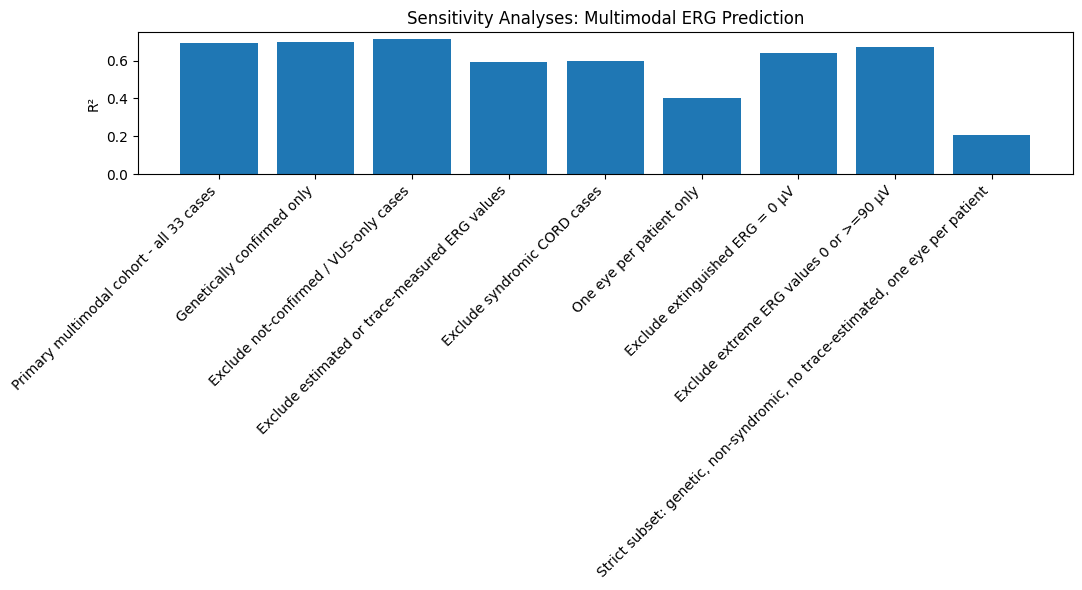

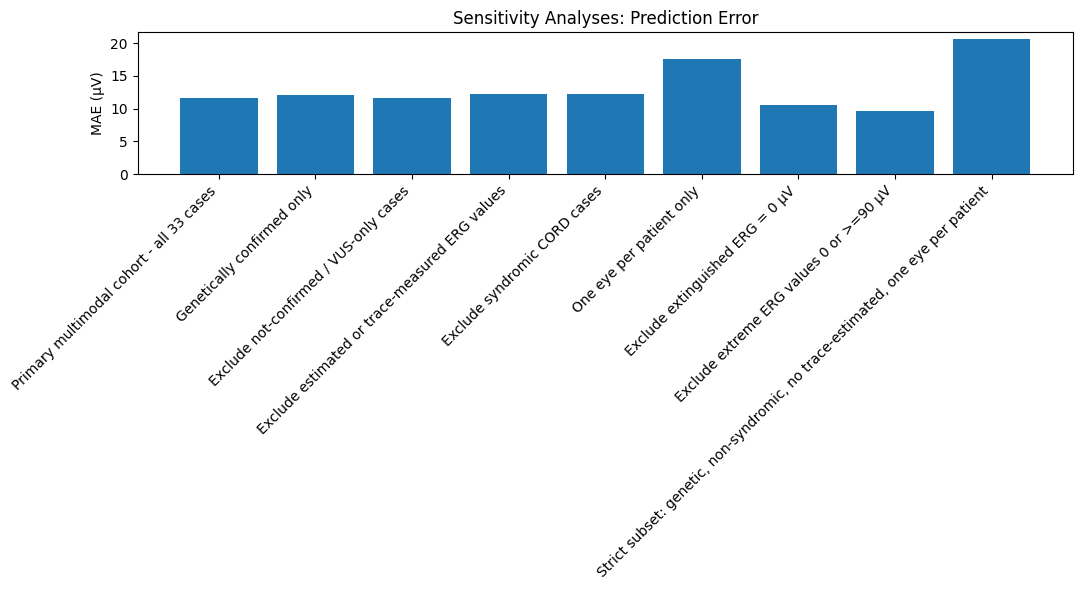

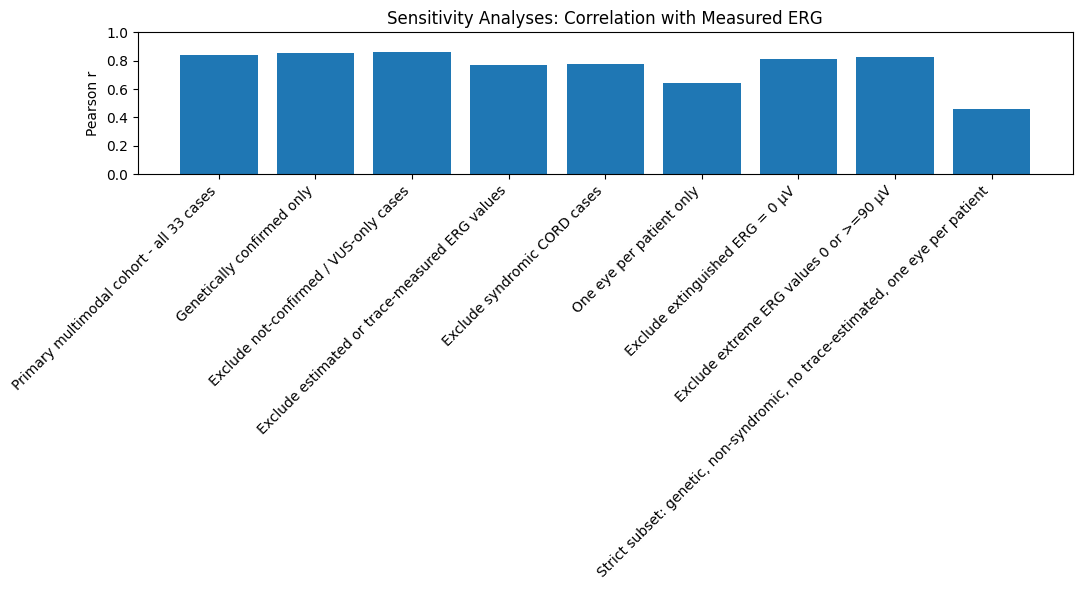


Saved files:
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_analysis_summary.csv
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_analysis_summary_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_analysis_predictions.csv
/content/drive/MyDrive/CORD project/STEP11E_robustness_summary_vs_primary.csv
/content/drive/MyDrive/CORD project/STEP11E_robustness_summary_vs_primary_poster_rounded.csv
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_R2_plot.png
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_MAE_plot.png
/content/drive/MyDrive/CORD project/STEP11E_sensitivity_Pearson_plot.png


In [10]:
# ============================================================
# STEP 11E
# CELL 3: Run sensitivity analyses
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

PROJECT_ROOT = "/content/drive/MyDrive/CORD project"

RANDOM_SEED = 42
N_BOOT = 5000

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# Helper functions
# ============================================================

def regression_metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)

    if len(np.unique(y)) > 1 and len(np.unique(pred)) > 1:
        pr = pearsonr(y, pred)
        sr = spearmanr(y, pred)

        pearson_r = pr.statistic
        pearson_p = pr.pvalue
        spearman_r = sr.statistic
        spearman_p = sr.pvalue
    else:
        pearson_r = np.nan
        pearson_p = np.nan
        spearman_r = np.nan
        spearman_p = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p
    }

def bootstrap_ci(values):
    values = np.asarray(values)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    return np.percentile(values, 2.5), np.percentile(values, 97.5)

def bootstrap_metric_ci(y, pred, n_boot=5000):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    boot_mae = []
    boot_rmse = []
    boot_r2 = []
    boot_pr = []
    boot_sr = []

    n = len(y)

    for i in range(n_boot):
        idx = rng.integers(0, n, n)

        try:
            m = regression_metrics(y[idx], pred[idx])

            boot_mae.append(m["MAE"])
            boot_rmse.append(m["RMSE"])
            boot_r2.append(m["R2"])
            boot_pr.append(m["Pearson_r"])
            boot_sr.append(m["Spearman_r"])
        except Exception:
            continue

    mae_low, mae_high = bootstrap_ci(boot_mae)
    rmse_low, rmse_high = bootstrap_ci(boot_rmse)
    r2_low, r2_high = bootstrap_ci(boot_r2)
    pr_low, pr_high = bootstrap_ci(boot_pr)
    sr_low, sr_high = bootstrap_ci(boot_sr)

    return {
        "MAE_95CI_low": mae_low,
        "MAE_95CI_high": mae_high,
        "RMSE_95CI_low": rmse_low,
        "RMSE_95CI_high": rmse_high,
        "R2_95CI_low": r2_low,
        "R2_95CI_high": r2_high,
        "Pearson_r_95CI_low": pr_low,
        "Pearson_r_95CI_high": pr_high,
        "Spearman_r_95CI_low": sr_low,
        "Spearman_r_95CI_high": sr_high
    }

def run_ridge_loo(features, y):
    alphas = np.logspace(-3, 3, 30)
    model = RidgeCV(alphas=alphas)

    loo = LeaveOneOut()
    pred = cross_val_predict(model, features, y, cv=loo)

    model.fit(features, y)

    return pred

def case_list_text(case_ids):
    return ", ".join([str(int(x)) for x in sorted(case_ids)])

# ============================================================
# Define sensitivity groups
# ============================================================

sensitivity_groups = {
    "Primary multimodal cohort - all 33 cases":
        multi["CaseID"].notna(),

    "Genetically confirmed only":
        multi["Is_Genetic"] == True,

    "Exclude not-confirmed / VUS-only cases":
        multi["Is_Not_Confirmed"] == False,

    "Exclude estimated or trace-measured ERG values":
        multi["Is_Estimated_or_TraceMeasured_ERG"] == False,

    "Exclude syndromic CORD cases":
        multi["Is_Syndromic"] == False,

    "One eye per patient only":
        multi["One_Eye_Per_Patient"] == True,

    "Exclude extinguished ERG = 0 µV":
        multi["Is_Extinguished_0"] == False,

    "Exclude extreme ERG values 0 or >=90 µV":
        multi["Is_Extreme_0_or_high"] == False,

    "Strict subset: genetic, non-syndromic, no trace-estimated, one eye per patient":
        (
            (multi["Is_Genetic"] == True) &
            (multi["Is_Syndromic"] == False) &
            (multi["Is_Estimated_or_TraceMeasured_ERG"] == False) &
            (multi["One_Eye_Per_Patient"] == True)
        )
}

# ============================================================
# Run sensitivity analyses
# ============================================================

summary_rows = []
prediction_rows = []

for analysis_name, mask in sensitivity_groups.items():

    subset = multi[mask].copy()
    subset_indices = subset.index.values
    n = len(subset)

    print("\n====================================================")
    print(analysis_name)
    print("N:", n)
    print("Cases:", case_list_text(subset["CaseID"]))

    if n < 8:
        print("Skipped because N < 8")
        continue

    y = subset["ERG30Hz"].values.astype(float)
    features = feat_multi[subset_indices, :]

    pred = run_ridge_loo(features, y)

    metrics = regression_metrics(y, pred)
    ci = bootstrap_metric_ci(y, pred, n_boot=N_BOOT)

    row = {
        "Sensitivity_Analysis": analysis_name,
        "N": n,
        "CaseIDs": case_list_text(subset["CaseID"]),
        "ERG_min": np.min(y),
        "ERG_max": np.max(y),
        "ERG_mean": np.mean(y),

        "MAE": metrics["MAE"],
        "MAE_95CI_low": ci["MAE_95CI_low"],
        "MAE_95CI_high": ci["MAE_95CI_high"],

        "RMSE": metrics["RMSE"],
        "RMSE_95CI_low": ci["RMSE_95CI_low"],
        "RMSE_95CI_high": ci["RMSE_95CI_high"],

        "R2": metrics["R2"],
        "R2_95CI_low": ci["R2_95CI_low"],
        "R2_95CI_high": ci["R2_95CI_high"],

        "Pearson_r": metrics["Pearson_r"],
        "Pearson_p": metrics["Pearson_p"],
        "Pearson_r_95CI_low": ci["Pearson_r_95CI_low"],
        "Pearson_r_95CI_high": ci["Pearson_r_95CI_high"],

        "Spearman_r": metrics["Spearman_r"],
        "Spearman_p": metrics["Spearman_p"],
        "Spearman_r_95CI_low": ci["Spearman_r_95CI_low"],
        "Spearman_r_95CI_high": ci["Spearman_r_95CI_high"],
    }

    summary_rows.append(row)

    temp_pred = subset.copy()
    temp_pred["Sensitivity_Analysis"] = analysis_name
    temp_pred["Predicted_ERG30Hz"] = pred
    temp_pred["Prediction_Error"] = temp_pred["Predicted_ERG30Hz"] - temp_pred["ERG30Hz"]
    temp_pred["Absolute_Error"] = abs(temp_pred["Prediction_Error"])

    prediction_rows.append(temp_pred)

    print("R2:", metrics["R2"])
    print("MAE:", metrics["MAE"])
    print("Pearson r:", metrics["Pearson_r"])
    print("Spearman r:", metrics["Spearman_r"])

# ============================================================
# Results tables
# ============================================================

sensitivity_summary = pd.DataFrame(summary_rows)

print("\n===== Sensitivity analysis summary =====")
display(sensitivity_summary)

sensitivity_poster = sensitivity_summary.copy()

for col in sensitivity_poster.columns:
    if sensitivity_poster[col].dtype != "object":
        sensitivity_poster[col] = sensitivity_poster[col].round(3)

print("\n===== Poster-friendly sensitivity analysis table =====")
display(sensitivity_poster)

sensitivity_summary.to_csv(
    PROJECT_ROOT + "/STEP11E_sensitivity_analysis_summary.csv",
    index=False
)

sensitivity_poster.to_csv(
    PROJECT_ROOT + "/STEP11E_sensitivity_analysis_summary_poster_rounded.csv",
    index=False
)

if len(prediction_rows) > 0:
    all_predictions = pd.concat(prediction_rows, ignore_index=True)
    all_predictions.to_csv(
        PROJECT_ROOT + "/STEP11E_sensitivity_analysis_predictions.csv",
        index=False
    )

# ============================================================
# Robustness compared with primary model
# ============================================================

primary = sensitivity_summary[
    sensitivity_summary["Sensitivity_Analysis"] == "Primary multimodal cohort - all 33 cases"
].iloc[0]

robustness_rows = []

for _, row in sensitivity_summary.iterrows():
    robustness_rows.append({
        "Sensitivity_Analysis": row["Sensitivity_Analysis"],
        "N": row["N"],

        "R2": row["R2"],
        "Change_in_R2_vs_primary": row["R2"] - primary["R2"],

        "MAE": row["MAE"],
        "Change_in_MAE_vs_primary": row["MAE"] - primary["MAE"],

        "Pearson_r": row["Pearson_r"],
        "Change_in_Pearson_r_vs_primary": row["Pearson_r"] - primary["Pearson_r"],

        "Spearman_r": row["Spearman_r"],
        "Change_in_Spearman_r_vs_primary": row["Spearman_r"] - primary["Spearman_r"]
    })

robustness_summary = pd.DataFrame(robustness_rows)

print("\n===== Robustness summary compared with primary multimodal model =====")
display(robustness_summary)

robustness_poster = robustness_summary.copy()

for col in robustness_poster.columns:
    if robustness_poster[col].dtype != "object":
        robustness_poster[col] = robustness_poster[col].round(3)

print("\n===== Poster-friendly robustness summary =====")
display(robustness_poster)

robustness_summary.to_csv(
    PROJECT_ROOT + "/STEP11E_robustness_summary_vs_primary.csv",
    index=False
)

robustness_poster.to_csv(
    PROJECT_ROOT + "/STEP11E_robustness_summary_vs_primary_poster_rounded.csv",
    index=False
)

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(11, 6))
plt.bar(sensitivity_poster["Sensitivity_Analysis"], sensitivity_poster["R2"])
plt.ylabel("R²")
plt.title("Sensitivity Analyses: Multimodal ERG Prediction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/STEP11E_sensitivity_R2_plot.png", dpi=300)
plt.show()

plt.figure(figsize=(11, 6))
plt.bar(sensitivity_poster["Sensitivity_Analysis"], sensitivity_poster["MAE"])
plt.ylabel("MAE (µV)")
plt.title("Sensitivity Analyses: Prediction Error")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/STEP11E_sensitivity_MAE_plot.png", dpi=300)
plt.show()

plt.figure(figsize=(11, 6))
plt.bar(sensitivity_poster["Sensitivity_Analysis"], sensitivity_poster["Pearson_r"])
plt.ylabel("Pearson r")
plt.title("Sensitivity Analyses: Correlation with Measured ERG")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(PROJECT_ROOT + "/STEP11E_sensitivity_Pearson_plot.png", dpi=300)
plt.show()

print("\nSaved files:")
print(PROJECT_ROOT + "/STEP11E_sensitivity_analysis_summary.csv")
print(PROJECT_ROOT + "/STEP11E_sensitivity_analysis_summary_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11E_sensitivity_analysis_predictions.csv")
print(PROJECT_ROOT + "/STEP11E_robustness_summary_vs_primary.csv")
print(PROJECT_ROOT + "/STEP11E_robustness_summary_vs_primary_poster_rounded.csv")
print(PROJECT_ROOT + "/STEP11E_sensitivity_R2_plot.png")
print(PROJECT_ROOT + "/STEP11E_sensitivity_MAE_plot.png")
print(PROJECT_ROOT + "/STEP11E_sensitivity_Pearson_plot.png")